# Cuaderno de limpieza de Pedro Herrero Bas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [2]:
import sys
from pathlib import Path

ROOT_DIR = Path().resolve().parents[1]
sys.path.append(str(ROOT_DIR))

from src import utils as ut

In [3]:
df = pd.read_csv('../../data/processed/dataset_final.csv')
df

,año,comunidad_autonoma,poblacion,pib_total,pib_pc,ingresos_pc,renta_pc,renta_media,renta_mediana,tasa_natalidad,...,paro,gasto_elevado_vivienda,falta_espacio_vivienda,retrasos_pagos,riesgo_pobreza,dificultad_fin_mes,desigualdad_ing(S80/S20),inc_gastos_imprevistos,precio_venta_m2,precio_alquiler_m2
0,2009,Andalucía,7627743.0,145802256.0,19.114731,9437.0,11869.0,143930.0,126950.0,11.48,...,17.73,8.6,5.7,10.6,27.7,71.8,6.0,45.7,1757.50,7.27
1,2010,Andalucía,7666919.0,145853901.0,19.023796,9882.0,11773.0,141520.0,120860.0,11.10,...,25.24,7.8,4.6,12.9,28.1,73.9,6.2,52.2,1713.33,6.85
2,2011,Andalucía,7693947.0,144494494.0,18.780282,9793.0,11797.0,13310.0,113690.0,10.72,...,27.77,11.2,7.5,13.8,34.5,70.5,7.3,49.6,1723.42,6.72
3,2012,Andalucía,7702875.0,139052618.0,18.052041,9241.0,11155.0,133910.0,111170.0,10.30,...,30.13,8.7,6.6,15.5,35.6,71.6,6.2,51.4,1579.42,6.43
4,2013,Andalucía,7710575.0,137294091.0,17.805947,9361.0,11100.0,127050.0,108660.0,9.71,...,34.35,9.2,6.4,13.4,40.1,75.4,6.6,55.5,1443.42,6.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,2018,Rioja,280018.0,8649852.0,30.890343,12561.0,16401.0,17490.0,15410.0,7.45,...,12.00,9.4,0.0,7.9,19.1,37.8,5.7,30.3,1180.17,5.89
262,2019,Rioja,279568.0,8889997.0,31.799051,12589.0,16765.0,186610.0,165770.0,7.66,...,10.40,5.8,2.1,4.9,17.5,25.4,5.0,19.0,1205.67,6.21
263,2020,Rioja,279704.0,8186915.0,29.269925,13371.0,16489.0,196980.0,175890.0,7.33,...,9.96,4.6,2.6,8.2,16.9,27.7,4.7,24.5,1215.08,6.58
264,2021,Rioja,278905.0,8735750.0,31.321597,14303.0,16951.0,187580.0,17420.0,6.94,...,10.80,8.2,3.7,8.0,16.8,32.3,5.1,22.5,1238.25,6.83


In [4]:
def filtrar_columna(df:pd.DataFrame, columna:str):
    '''
    Función para dividir un Dataset, en una lista de Dataset según los valores de una columna.
    '''
    lista_df = []
    lista_valores = df[columna].unique().tolist()
    for valor in lista_valores:
        lista_df.append(df[df[columna] == valor].set_index(columna))
    return lista_df

In [5]:
df_com = filtrar_columna(df, 'comunidad_autonoma')

In [6]:
df_com[0].index[0]

'Andalucía'

In [7]:
p_matrices = {df.index[0]: ut.pearson_p_matrix(df) for df in df_com}
len(p_matrices)

19

In [8]:
p_matrices['Madrid']

,año,poblacion,pib_total,pib_pc,ingresos_pc,renta_pc,renta_media,renta_mediana,tasa_natalidad,tasa_suicidio,...,paro,gasto_elevado_vivienda,falta_espacio_vivienda,retrasos_pagos,riesgo_pobreza,dificultad_fin_mes,desigualdad_ing(S80/S20),inc_gastos_imprevistos,precio_venta_m2,precio_alquiler_m2
año,0.000000e+00,1.292084e-09,3.384407e-05,1.497602e-03,0.015097,5.085745e-05,0.186045,0.628639,4.585907e-12,1.342031e-03,...,3.876154e-01,0.134529,3.853467e-01,0.784518,0.824067,0.000488,0.945628,4.391803e-03,0.149582,0.000328
poblacion,1.292084e-09,0.000000e+00,5.627322e-04,1.045629e-02,0.071632,5.789934e-04,0.192416,0.845941,1.156166e-08,6.765840e-04,...,6.112231e-01,0.183728,5.349730e-01,0.899693,0.446963,0.002199,0.737172,8.620740e-03,0.391320,0.001198
pib_total,3.384407e-05,5.627322e-04,1.730348e-93,1.709430e-09,0.012608,1.983645e-08,0.217172,0.325070,8.462168e-05,1.425292e-02,...,7.632904e-02,0.236394,7.250708e-01,0.787900,0.504462,0.000128,0.712599,1.519769e-03,0.018650,0.000041
pib_pc,1.497602e-03,1.045629e-02,1.709430e-09,0.000000e+00,0.014661,7.686491e-07,0.275501,0.240373,2.502500e-03,5.316489e-02,...,3.465449e-02,0.311681,8.238440e-01,0.706402,0.261349,0.000468,0.570772,3.048191e-03,0.006489,0.000217
ingresos_pc,1.509734e-02,7.163192e-02,1.260848e-02,1.466150e-02,0.000000,1.135861e-02,0.451095,0.112084,8.269326e-03,4.676927e-01,...,1.099658e-01,0.005184,1.380020e-02,0.093586,0.016528,0.010141,0.013614,1.275105e-01,0.000190,0.008931
renta_pc,5.085745e-05,5.789934e-04,1.983645e-08,7.686491e-07,0.011359,0.000000e+00,0.123089,0.328055,1.047509e-04,8.920181e-03,...,3.796781e-02,0.177844,4.941211e-01,0.722222,0.427505,0.000002,0.754949,8.782923e-05,0.013513,0.000004
renta_media,1.860447e-01,1.924161e-01,2.171722e-01,2.755012e-01,0.451095,1.230892e-01,0.000000,0.777523,1.665548e-01,2.779681e-01,...,6.064850e-01,0.985428,6.910967e-01,0.972181,0.915614,0.103861,0.702880,2.312622e-01,0.342199,0.210489
renta_mediana,6.286391e-01,8.459412e-01,3.250699e-01,2.403735e-01,0.112084,3.280552e-01,0.777523,0.000000,4.937576e-01,5.275757e-01,...,6.597584e-02,0.759372,5.696357e-01,0.445715,0.102167,0.263603,0.201920,7.577098e-01,0.052249,0.167717
tasa_natalidad,4.585907e-12,1.156166e-08,8.462168e-05,2.502500e-03,0.008269,1.047509e-04,0.166555,0.493758,1.730348e-93,4.502945e-03,...,3.164883e-01,0.084346,2.745009e-01,0.690882,0.971265,0.000352,0.732771,5.919910e-03,0.103966,0.000164
tasa_suicidio,1.342031e-03,6.765840e-04,1.425292e-02,5.316489e-02,0.467693,8.920181e-03,0.277968,0.527576,4.502945e-03,1.107422e-91,...,6.798973e-01,0.662874,9.294871e-01,0.904893,0.247348,0.024313,0.319477,2.961114e-03,0.833099,0.033025


In [9]:
corr_matrices = {df.index[0]: df.corr() for df in df_com}
len(corr_matrices)

19

In [10]:
corr_matrices['Madrid']

,año,poblacion,pib_total,pib_pc,ingresos_pc,renta_pc,renta_media,renta_mediana,tasa_natalidad,tasa_suicidio,...,paro,gasto_elevado_vivienda,falta_espacio_vivienda,retrasos_pagos,riesgo_pobreza,dificultad_fin_mes,desigualdad_ing(S80/S20),inc_gastos_imprevistos,precio_venta_m2,precio_alquiler_m2
año,1.000000,0.978688,0.879551,0.763119,0.633040,0.870661,-0.375323,0.141825,-0.991715,0.767841,...,-0.250544,-0.420338,0.251705,0.080462,0.065456,-0.806817,-0.020099,-0.710619,0.406156,0.820098
poblacion,0.978688,1.000000,0.801787,0.658436,0.495436,0.800765,-0.370348,0.057222,-0.969187,0.795074,...,-0.148984,-0.377158,0.181341,-0.037139,0.221345,-0.745716,0.098674,-0.670941,0.248656,0.772611
pib_total,0.879551,0.801787,1.000000,0.977662,0.645768,0.966251,-0.351955,0.284020,-0.858562,0.637166,...,-0.488500,-0.338561,0.103379,0.079173,-0.194836,-0.847905,-0.108253,-0.762478,0.617397,0.875347
pib_pc,0.763119,0.658436,0.977662,1.000000,0.635147,0.937258,-0.313234,0.335873,-0.739540,0.526360,...,-0.566552,-0.291642,0.065540,0.110685,-0.322132,-0.808263,-0.165928,-0.729789,0.688380,0.832869
ingresos_pc,0.633040,0.495436,0.645768,0.635147,1.000000,0.652901,-0.219386,0.443621,-0.673566,0.211609,...,-0.445976,-0.701403,0.639455,0.465343,-0.626437,-0.660453,-0.640416,-0.427315,0.836781,0.668694
renta_pc,0.870661,0.800765,0.966251,0.937258,0.652901,1.000000,-0.431845,0.282345,-0.853140,0.668769,...,-0.558357,-0.381889,0.199494,0.104490,-0.230687,-0.925617,-0.091800,-0.857632,0.640937,0.917703
renta_media,-0.375323,-0.370348,-0.351955,-0.313234,-0.219386,-0.431845,1.000000,-0.083135,0.391257,-0.311710,...,0.150946,-0.005383,0.116719,0.010279,-0.031224,0.452945,-0.112069,0.342069,-0.274523,-0.356784
renta_mediana,0.141825,0.057222,0.284020,0.335873,0.443621,0.282345,-0.083135,1.000000,-0.199659,-0.184580,...,-0.504230,-0.090097,0.166410,0.221938,-0.454929,-0.320696,-0.363120,-0.090737,0.528084,0.390274
tasa_natalidad,-0.991715,-0.969187,-0.858562,-0.739540,-0.673566,-0.853140,0.391257,-0.199659,1.000000,-0.709251,...,0.288884,0.477329,-0.313854,-0.116804,-0.010617,0.817848,0.100382,0.693781,-0.452823,-0.841102
tasa_suicidio,0.767841,0.795074,0.637166,0.526360,0.211609,0.668769,-0.311710,-0.184580,-0.709251,1.000000,...,-0.121161,-0.127961,0.026078,0.035206,0.331226,-0.596599,0.287182,-0.731247,0.062051,0.570797


In [11]:
def corr_to_vector(corr_df):
    '''Convierte una matriz de correlación en un vector de una dimensión con todos los valores cruzados.'''
    return (corr_df.where(np.triu(np.ones(corr_df.shape), k=1).astype(bool)).stack())

# DataFrame: filas = datasets, columnas = pares de variables
corr_vectors = pd.DataFrame([corr_to_vector(matriz) for matriz in corr_matrices.values()])

corr_vectors.index = [key for key in corr_matrices.keys()]
corr_vectors

año                                            \
                     poblacion pib_total    pib_pc ingresos_pc  renta_pc   
Andalucía             0.843310  0.796477  0.764902    0.307417  0.830452   
Aragón               -0.732143  0.805034  0.805885    0.657572  0.836420   
Asturias             -0.994330  0.554838  0.729260    0.382205  0.863784   
Balears               0.990889  0.739768  0.541000    0.484590  0.767489   
Canarias              0.980783  0.614250  0.467127    0.515176  0.796492   
Cantabria            -0.811445  0.742284  0.755632    0.459939  0.843329   
Castilla - La Mancha -0.483599  0.723787  0.723167    0.336975  0.873895   
Castilla Y León      -0.993971  0.715210  0.825497    0.780713  0.878670   
Cataluña              0.931381  0.849957  0.797477    0.706280  0.827202   
Ceuta                 0.577390  0.809736  0.676601    0.562374  0.681798   
Comunitat Valenciana  0.965446  0.803639  0.761417    0.350546  0.852402   
Extremadura          -0.957544  0.825785  0.855555    0.345423  0.913446   
Galicia              -0.996784  0.817789  0.862043    0.887528  0.891046   
Madrid                0.978688  0.879551  0.763119    0.633040  0.870661   
Melilla               0.911776  0.870554  0.499959    0.176761  0.627456   
Murcia                0.998075  0.856204  0.772676    0.227853  0.841843   
Navarra               0.937761  0.837942  0.744617    0.370039  0.656848   
País Vasco           -0.273248  0.823202  0.817188    0.678866  0.803000   
Rioja                 0.708159  0.781367  0.734477    0.811014  0.859671   

                                                                             \
                     renta_media renta_mediana tasa_natalidad tasa_suicidio   
Andalucía               0.298569      0.400760      -0.992357     -0.469589   
Aragón                 -0.194782      0.527624      -0.986057      0.326137   
Asturias                0.364704      0.039326      -0.981548      0.173727   
Balears                -0.085185      0.105509      -0.982874     -0.657127   
Canarias               -0.111297      0.204700      -0.980841      0.236305   
Cantabria               0.057498      0.532929      -0.996174      0.537352   
Castilla - La Mancha    0.289231     -0.230107      -0.991296     -0.027022   
Castilla Y León         0.351876     -0.105910      -0.990941      0.442991   
Cataluña                0.477157      0.172955      -0.991957      0.652973   
Ceuta                   0.480960     -0.443378      -0.954624     -0.163201   
Comunitat Valenciana    0.508993      0.309519      -0.991228      0.169689   
Extremadura             0.261359      0.331319      -0.981116      0.127759   
Galicia                 0.282999      0.223958      -0.981640     -0.113362   
Madrid                 -0.375323      0.141825      -0.991715      0.767841   
Melilla                 0.200095      0.066936      -0.835753     -0.484784   
Murcia                  0.574676     -0.332443      -0.991297      0.218028   
Navarra                 0.185241      0.066936      -0.985858     -0.366774   
País Vasco             -0.211021      0.457219      -0.980627     -0.216717   
Rioja                   0.178485     -0.188456      -0.988903     -0.153608   

                                     ...       dificultad_fin_mes  \
                     tasa_homicidio  ... desigualdad_ing(S80/S20)   
Andalucía                 -0.458932  ...                 0.590883   
Aragón                    -0.235263  ...                 0.630566   
Asturias                  -0.711821  ...                -0.446911   
Balears                   -0.422179  ...                 0.406413   
Canarias                  -0.073211  ...                 0.544058   
Cantabria                  0.132531  ...                 0.007289   
Castilla - La Mancha       0.193652  ...                 0.598385   
Castilla Y León            0.063890  ...                 0.696254   
Cataluña                  -0.660504  ...                 0.480933   
Ceuta      

In [12]:
corr_summary = pd.DataFrame({'mean': corr_vectors.mean(), 'std': corr_vectors.std()})
corr_summary.head()

mean       std
año poblacion    0.188452  0.871445
    pib_total    0.781441  0.084470
    pib_pc       0.731453  0.112261
    ingresos_pc  0.509174  0.206338
    renta_pc     0.816627  0.079882

In [13]:
def std_category(std):
    if std < 0.05:
        return "low"       # círculo
    elif std < 0.10:
        return "medium"    # cuadrado
    else:
        return "high"      # triángulo

corr_summary["std_cat"] = corr_summary["std"].apply(std_category)
corr_summary

mean       std std_cat
año                      poblacion           0.188452  0.871445    high
                         pib_total           0.781441  0.084470  medium
                         pib_pc              0.731453  0.112261    high
                         ingresos_pc         0.509174  0.206338    high
                         renta_pc            0.816627  0.079882  medium
...                                               ...       ...     ...
desigualdad_ing(S80/S20) precio_venta_m2    -0.053721  0.464879    high
                         precio_alquiler_m2 -0.357261  0.328886    high
inc_gastos_imprevistos   precio_venta_m2    -0.118264  0.448083    high
                         precio_alquiler_m2 -0.330514  0.390208    high
precio_venta_m2          precio_alquiler_m2  0.307177  0.404925    high

[231 rows x 3 columns]

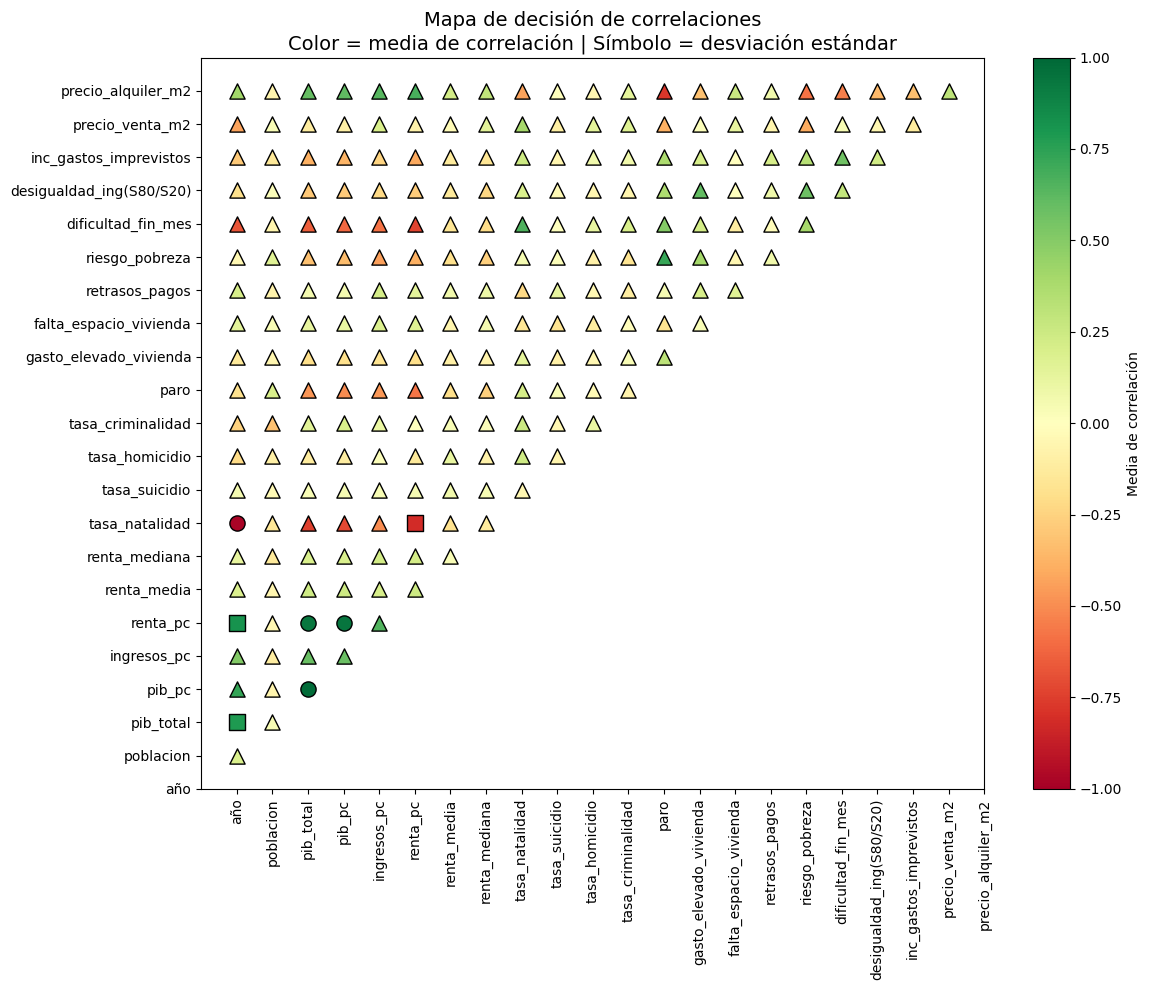

In [14]:
variables = corr_matrices['Madrid'].columns.tolist()
var_index = {v: i for i, v in enumerate(variables)}

fig, ax = plt.subplots(figsize=(12, 10))

for (var_x, var_y), row in corr_summary.iterrows():

    x = var_index[var_x]
    y = var_index[var_y]

    marker = {
        "low": "o",     # círculo
        "medium": "s",  # cuadrado
        "high": "^"     # triángulo
    }[row["std_cat"]]

    sc = ax.scatter(
        x,
        y,
        c=row["mean"],
        cmap="RdYlGn",
        vmin=-1,
        vmax=1,
        s=120,
        marker=marker,
        edgecolor="black"
    )

# Ejes
ax.set_xticks(range(len(variables)))
ax.set_yticks(range(len(variables)))
ax.set_xticklabels(variables, rotation=90)
ax.set_yticklabels(variables)

ax.set_title(
    "Mapa de decisión de correlaciones\n"
    "Color = media de correlación | Símbolo = desviación estándar",
    fontsize=14
)

# Barra de color
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Media de correlación")

plt.tight_layout()
plt.show()


*Tras esta primera representación se observan muchos triángulos y pocas variables con una correlación alta. Tras una busqueda en Internet se aplican diferentes palancas para conseguir evidencias relacionales más claras*

🔹 PALANCA 1 — Fisher Z-transform (CLAVE)

Promediar correlaciones en r es mala idea.

Solución:

Transformar primero:

r → z

promediar

volver a r

🔹 Qué hace Fisher Z

Transforma:

𝑧
=
tanh
⁡
−
1
(
𝑟
)
z=tanh
−1
(r)

Propiedades clave:

Distribución aproximadamente normal

Varianza independiente del valor de r

Pensado EXACTAMENTE para:

comparar

promediar

hacer meta-análisis

Después:

𝑟
=
tanh
⁡
(
𝑧
)
r=tanh(z)

👉 No cambia la correlación, cambia cómo la agregas.

🔹 Cuándo usar Fisher Z

✔️ Siempre que:

Promedias correlaciones

Comparas correlaciones entre muestras

Quieres estabilidad estadística

📌 En tu caso: obligatorio, no opcional.

In [15]:
from numpy import arctanh, tanh

z_vectors = corr_vectors.apply(np.arctanh)
z_mean = z_vectors.mean()
z_std = z_vectors.std()

summary = pd.DataFrame({
    "mean": np.tanh(z_mean),
    "std": z_std
})

🔹 PALANCA 2 — Relajar el concepto de “estabilidad”

Ahora mismo estás siendo muy duro.

Ejemplo más realista:

In [16]:
def std_category(std):
    if std < 0.10:
        return "low"
    elif std < 0.20:
        return "medium"
    else:
        return "high"


🔹 PALANCA 3 — Estabilidad de signo (muy potente)

Aunque el valor fluctúe, ¿el signo se mantiene?

In [17]:
sign_consistency = (corr_vectors > 0).mean().abs()

🔹 PALANCA 4 — Filtrar por magnitud mínima

Muchas correlaciones son “ruido pequeño”.

In [18]:
mask = corr_vectors.abs().mean() > 0.2
corr_vectors = corr_vectors.loc[:, mask]

4️⃣ Código COMPLETO aplicando 1–2–3–4

4.1 Fisher Z + estadísticas

In [19]:
# Fisher Z transform
z_vectors = corr_vectors.apply(np.arctanh)

summary = pd.DataFrame({
    "mean_r": np.tanh(z_vectors.mean()),   # media correcta
    "std_z": z_vectors.std(),               # variabilidad real
    "sign_consistency": (corr_vectors > 0).mean().abs()
})


4.2 Filtrar por magnitud (palanca 4)

In [20]:
summary = summary[summary["mean_r"].abs() > 0.2]

In [21]:
summary

mean_r     std_z  \
año                      poblacion               0.335642  2.054077   
                         pib_total               0.792717  0.197007   
                         pib_pc                  0.746972  0.220101   
                         ingresos_pc             0.546629  0.332427   
                         renta_pc                0.828775  0.215947   
...                                                   ...       ...   
dificultad_fin_mes       precio_alquiler_m2     -0.662432  0.746779   
desigualdad_ing(S80/S20) inc_gastos_imprevistos  0.261882  0.438739   
                         precio_alquiler_m2     -0.396385  0.389977   
inc_gastos_imprevistos   precio_alquiler_m2     -0.397741  0.534474   
precio_venta_m2          precio_alquiler_m2      0.386982  0.557885   

                                                 sign_consistency  
año                      poblacion                       0.578947  
                         pib_total                       1.000000  
                         pib_pc                          1.000000  
                         ingresos_pc                     1.000000  
                         renta_pc                        1.000000  
...                                                           ...  
dificultad_fin_mes       precio_alquiler_m2              0.105263  
desigualdad_ing(S80/S20) inc_gastos_imprevistos          0.789474  
                         precio_alquiler_m2              0.210526  
inc_gastos_imprevistos   precio_alquiler_m2              0.210526  
precio_venta_m2          precio_alquiler_m2              0.736842  

[112 rows x 3 columns]

4.3 Clasificar estabilidad (palanca 2)

In [22]:
def std_category(std):
    if std < 0.20:
        return "low"
    elif std < 0.40:
        return "medium"
    else:
        return "high"

summary["std_cat"] = summary["std_z"].apply(std_category)


5️⃣ Código de la GRÁFICA (final)

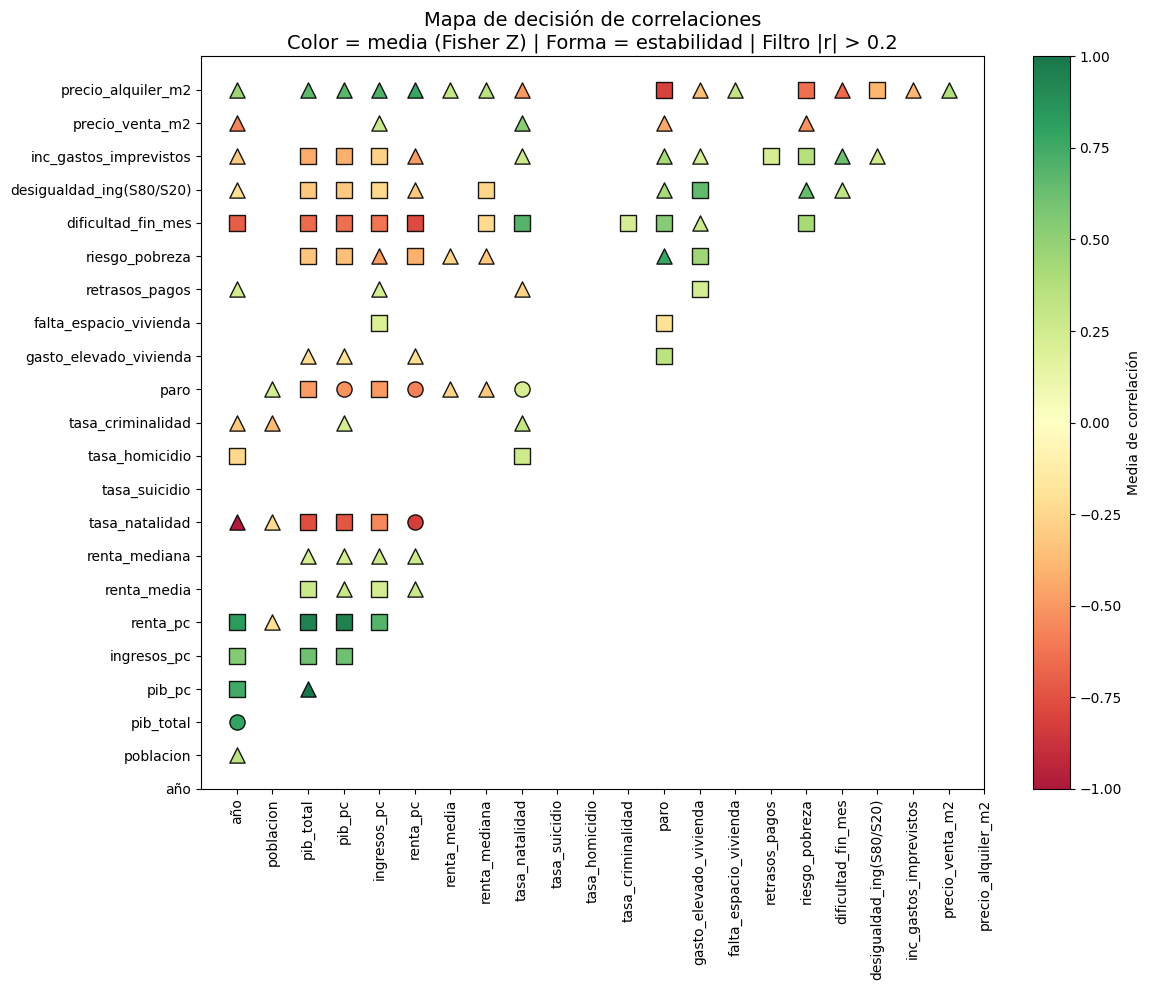

In [23]:
variables = corr_matrices['Madrid'].columns.tolist()
var_index = {v: i for i, v in enumerate(variables)}

fig, ax = plt.subplots(figsize=(12, 10))

for (var_x, var_y), row in summary.iterrows():

    x = var_index[var_x]
    y = var_index[var_y]

    marker = {
        "low": "o",
        "medium": "s",
        "high": "^"
    }[row["std_cat"]]

    sc = ax.scatter(
        x, y,
        c=row["mean_r"],
        cmap="RdYlGn",
        vmin=-1,
        vmax=1,
        s=120,
        marker=marker,
        edgecolor="black",
        alpha=0.9
    )

ax.set_xticks(range(len(variables)))
ax.set_yticks(range(len(variables)))
ax.set_xticklabels(variables, rotation=90)
ax.set_yticklabels(variables)

ax.set_title(
    "Mapa de decisión de correlaciones\n"
    "Color = media (Fisher Z) | Forma = estabilidad | Filtro |r| > 0.2",
    fontsize=14
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Media de correlación")

plt.tight_layout()
plt.show()


*Para una mayor agilidad en el análisis se crea la matriz simétrica y así tener el cuadro completo a la hora de buscar correlaciones.*

In [24]:
summary_sym = summary.copy()

# Intercambiar los pares (A, B) → (B, A)
summary_sym.index = pd.MultiIndex.from_tuples(
    [(j, i) for i, j in summary.index],
    names=summary.index.names
)

# Unir original + simétrica
summary_full = pd.concat([summary, summary_sym])


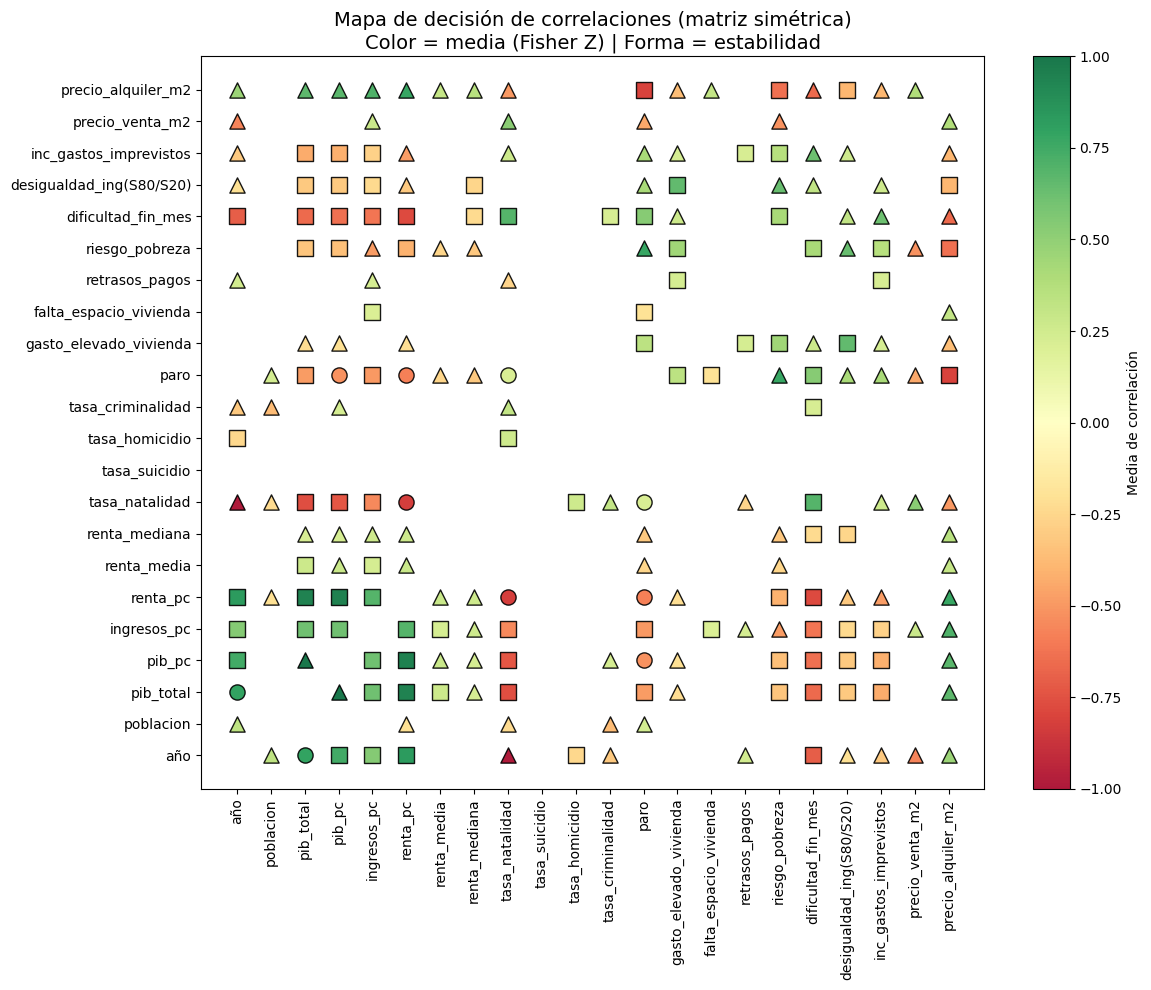

In [25]:
variables = corr_matrices['Madrid'].columns.tolist()
var_index = {v: i for i, v in enumerate(variables)}

fig, ax = plt.subplots(figsize=(12, 10))

for (var_x, var_y), row in summary_full.iterrows():

    x = var_index[var_x]
    y = var_index[var_y]

    marker = {
        "low": "o",
        "medium": "s",
        "high": "^"
    }[row["std_cat"]]

    sc = ax.scatter(
        x,
        y,
        c=row["mean_r"],
        cmap="RdYlGn",
        vmin=-1,
        vmax=1,
        s=120,
        marker=marker,
        edgecolor="black",
        alpha=0.9
    )

ax.set_xticks(range(len(variables)))
ax.set_yticks(range(len(variables)))
ax.set_xticklabels(variables, rotation=90)
ax.set_yticklabels(variables)

ax.set_title(
    "Mapa de decisión de correlaciones (matriz simétrica)\n"
    "Color = media (Fisher Z) | Forma = estabilidad",
    fontsize=14
)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Media de correlación")

plt.tight_layout()
plt.show()


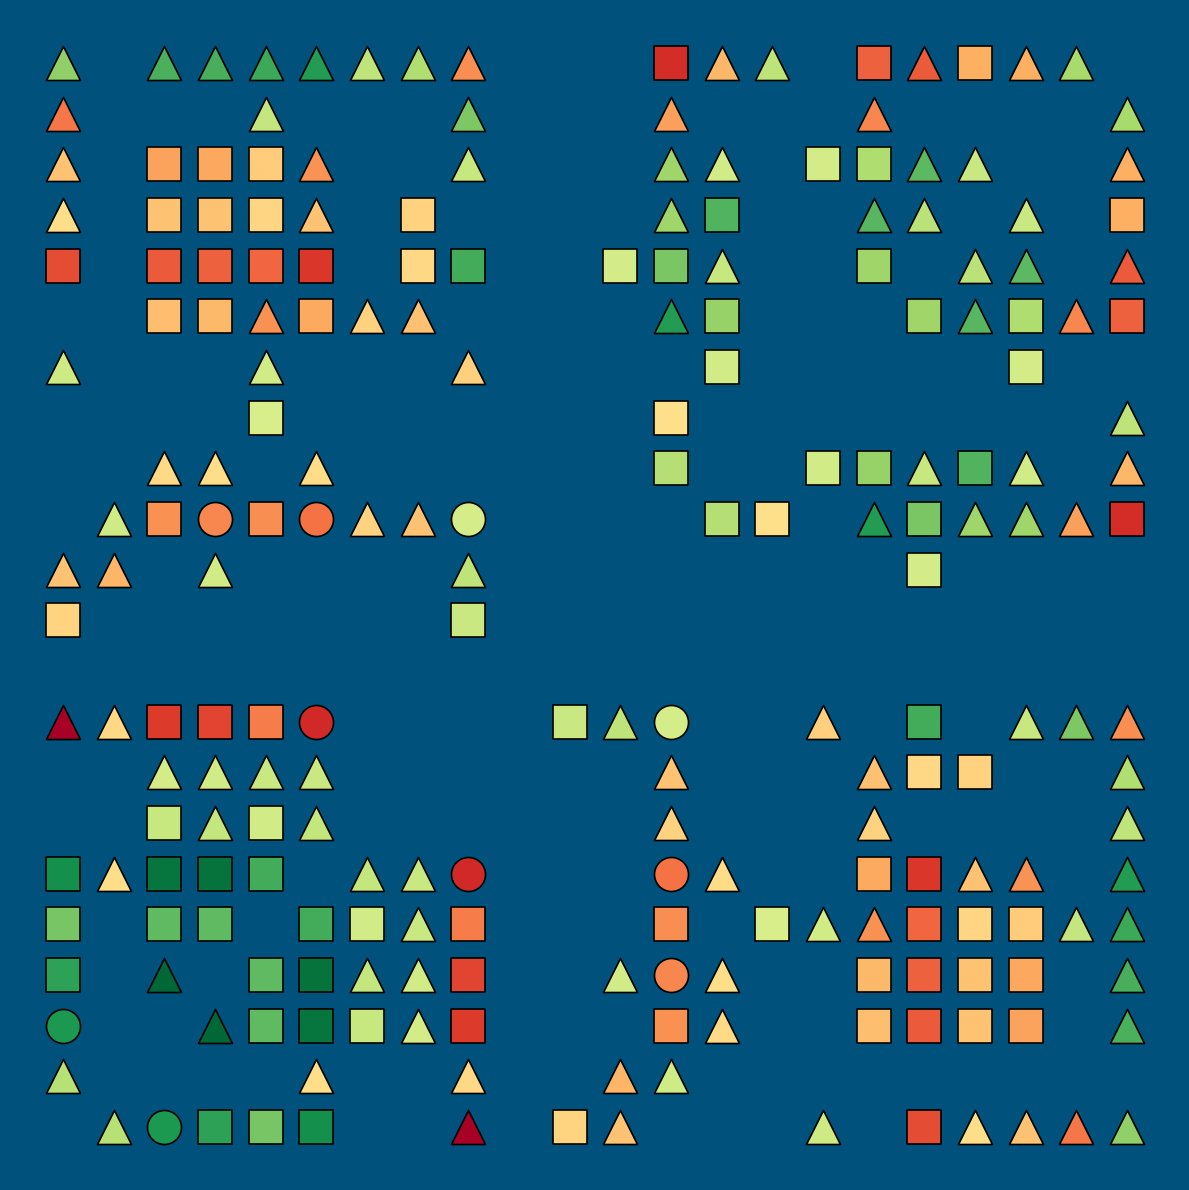

In [26]:
variables = corr_matrices['Madrid'].columns.tolist()
var_index = {v: i for i, v in enumerate(variables)}

fig, ax = plt.subplots(figsize=(12, 12))

# fondo azul claro
ax.set_facecolor("#00517c")
fig.patch.set_facecolor("#00517c")

for (var_x, var_y), row in summary_full.iterrows():

    x = var_index[var_x]
    y = var_index[var_y]

    marker = {
        "low": "o",
        "medium": "s",
        "high": "^"
    }[row["std_cat"]]

    ax.scatter(
        x,
        y,
        c=row["mean_r"],
        cmap="RdYlGn",
        vmin=-1,
        vmax=1,
        s=600,              # 🔥 marcadores grandes
        marker=marker,
        edgecolor="black",
        linewidth=1.2,
        alpha=1.0
    )

# quitar ticks y texto
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title("")

# quitar bordes
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()


precio_alquiler_m2 - paro / riesgo pobreza

precio_venta_m2 - Nada

inc_gastos_imprevistos - Nada

Desigualdad - Gasto_elevado_vivienda

Dificultad_fin - Natalidad / Renta PC

Rieso Pobreza - Tasa de Criminalidad

Retrasos pagos - Nada

Falta espacio vivienda - Nada

Paro - Nada

Suicidios - Nada (Mencionar el cambio de datos en 2013)

Tasa Criminalidad - Nada

Tasa homicidios - Nada

Tasa Natalidad - Año, Renta PC, PIB Total, Dificultad Fin de mes

Renta Mediana - Nada

Renta Media - Nada

Renta PC - Año, Pib total, pib per capita, Tasa de Natalidad, Dificultad fin de mes

Ingresos - Año, PIB total, Pib per capita, Renta PC

PIB PC - Año, PIB Total, Ingresos PC, Renta PC, Tasa Natalidad

In [27]:
corr_matrices['Madrid'].columns

Index(['año', 'poblacion', 'pib_total', 'pib_pc', 'ingresos_pc', 'renta_pc',
       'renta_media', 'renta_mediana', 'tasa_natalidad', 'tasa_suicidio',
       'tasa_homicidio', 'tasa_criminalidad', 'paro', 'gasto_elevado_vivienda',
       'falta_espacio_vivienda', 'retrasos_pagos', 'riesgo_pobreza',
       'dificultad_fin_mes', 'desigualdad_ing(S80/S20)',
       'inc_gastos_imprevistos', 'precio_venta_m2', 'precio_alquiler_m2'],
      dtype='object')

## PIB por Año

Con los resultados obtenidos en la anterior tabla se verifica que existe una alta correlación positiva entre el PIB y el año, de modo que a medida que han pasado los años el PIB ha crecido de manera estable y con poca variación en todas las comunidades autónomas. Para verificar esto, haremos un análisis más en profundidad de estas dos variables, desgranando por cada comunidad y buscando aquellos valores más representativos.

*Analizamos la correlación obtenida en cada una de las comunidades para representar aquellos valores que parezcan más interesantes.*

In [28]:
for comunidad, datos in corr_matrices.items():
    print(comunidad, '|', datos.loc['año', 'pib_total'], '|', p_matrices[comunidad].loc['año', 'pib_total'])

Andalucía | 0.796476555723015 | 0.0006513873376028277
Aragón | 0.8050340359248687 | 0.0005134958502300675
Asturias | 0.5548382016226177 | 0.03945967166231658
Balears | 0.7397677809225605 | 0.002490774207798018
Canarias | 0.6142500699884125 | 0.01943544291848523
Cantabria | 0.7422843185562694 | 0.0023638262634118564
Castilla - La Mancha | 0.723787423616433 | 0.0034279753042490762
Castilla Y León | 0.7152098389279955 | 0.004034364897704507
Cataluña | 0.8499569188532631 | 0.00011827526559966788
Ceuta | 0.8097362487475099 | 0.0004483842070766643
Comunitat Valenciana | 0.8036390072190042 | 0.0005342080672554936
Extremadura | 0.8257845678266488 | 0.00027422512245951194
Galicia | 0.8177892430409262 | 0.00035240090746974827
Madrid | 0.8795514355743195 | 3.384406744437442e-05
Melilla | 0.8705541800143266 | 5.1097404876979466e-05
Murcia | 0.8562036367904621 | 9.295051237360638e-05
Navarra | 0.8379419279311899 | 0.00018269107434038784
País Vasco | 0.8232015146613644 | 0.00029776854714401034
Rioja

*Para representar en una gráfica los valores de mayor interés seleccionaremos aquellos con mayor correlación (Madrid y Melilla), aquellos con menor (Asturias y Canarias) y uno intermedio (Rioja) para tener una idea aproximada del conjunto de valores.*

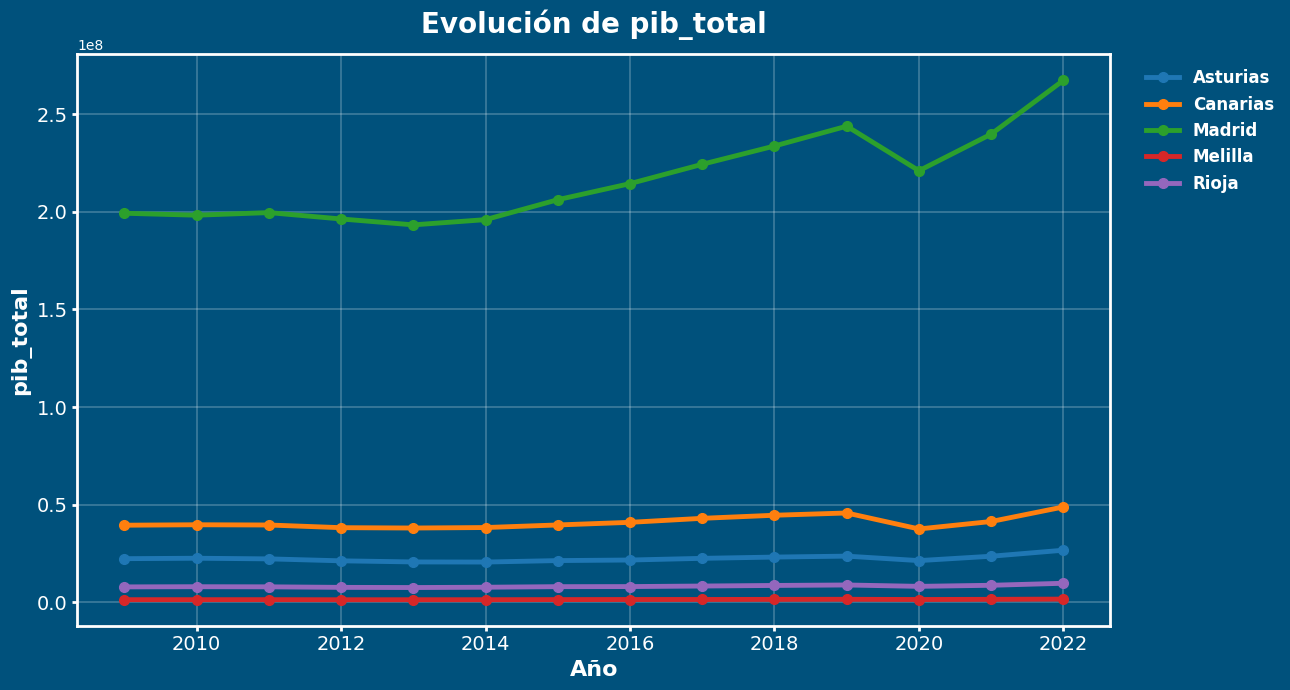

In [29]:
ut.plot_todas_comunidades(df, 'pib_total', ['Asturias', 'Canarias', 'Madrid', 'Melilla', 'Rioja']);

*Existe gran disparidad entre los valores representados ya que el PIB de Madrid es notablemente superior a las del resto, para amortiguar en parte esta representación, utilizaremos el PIB per Cápita.*

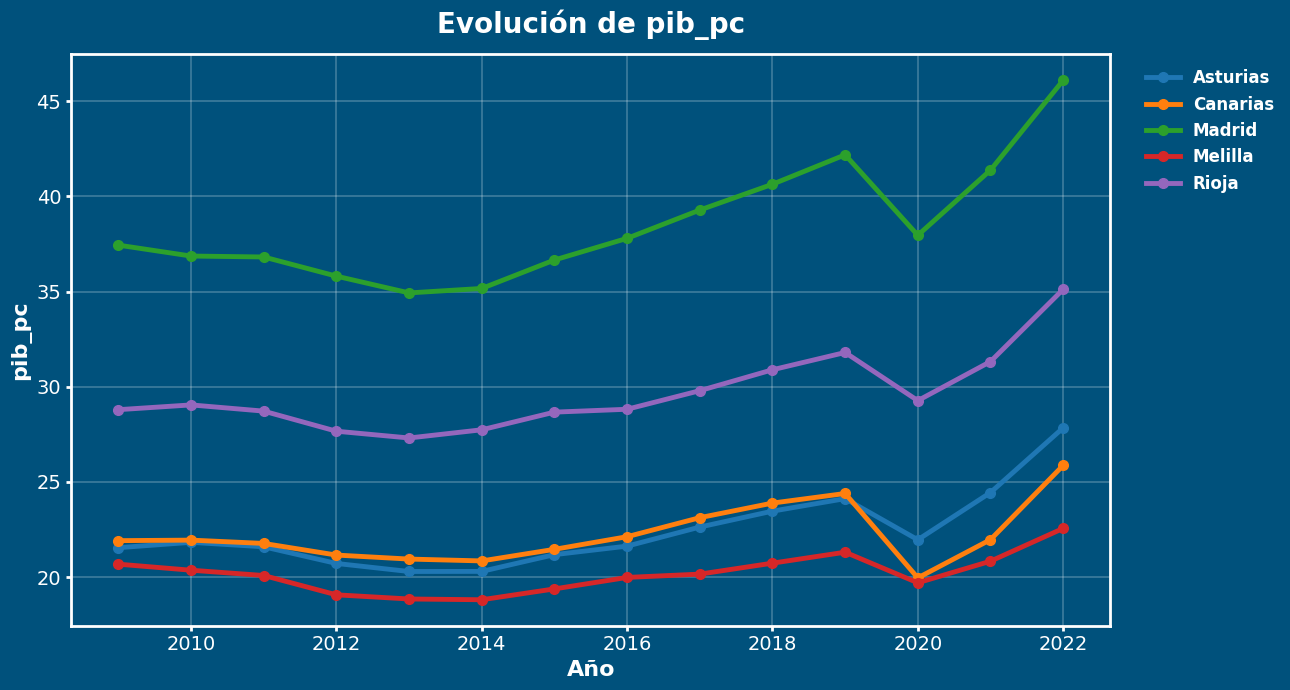

In [30]:
ut.plot_todas_comunidades(df, 'pib_pc', ['Asturias', 'Canarias', 'Madrid', 'Melilla', 'Rioja']);

*En esta gráfica se puede observar claramente lo que se intuía en la anterior, con los valores más cercanos entre si y permitiendonos ver de un simple vistazo el comportamiento de estos. El PIB es una variable que tiende a crecer con el tiempo, al menos durante los años de muestreo de este dataset. En todas las comunidades existe una clara tendencia ascendente, con un bache en el camino (añó 2020).*

*Para poder tener en consideración la gráfica anterior donde se representa el pib_pc a lo largo de los años, sería conveniente ver la evolución de la población a lo largo de los años en estas mismas comunidades.*

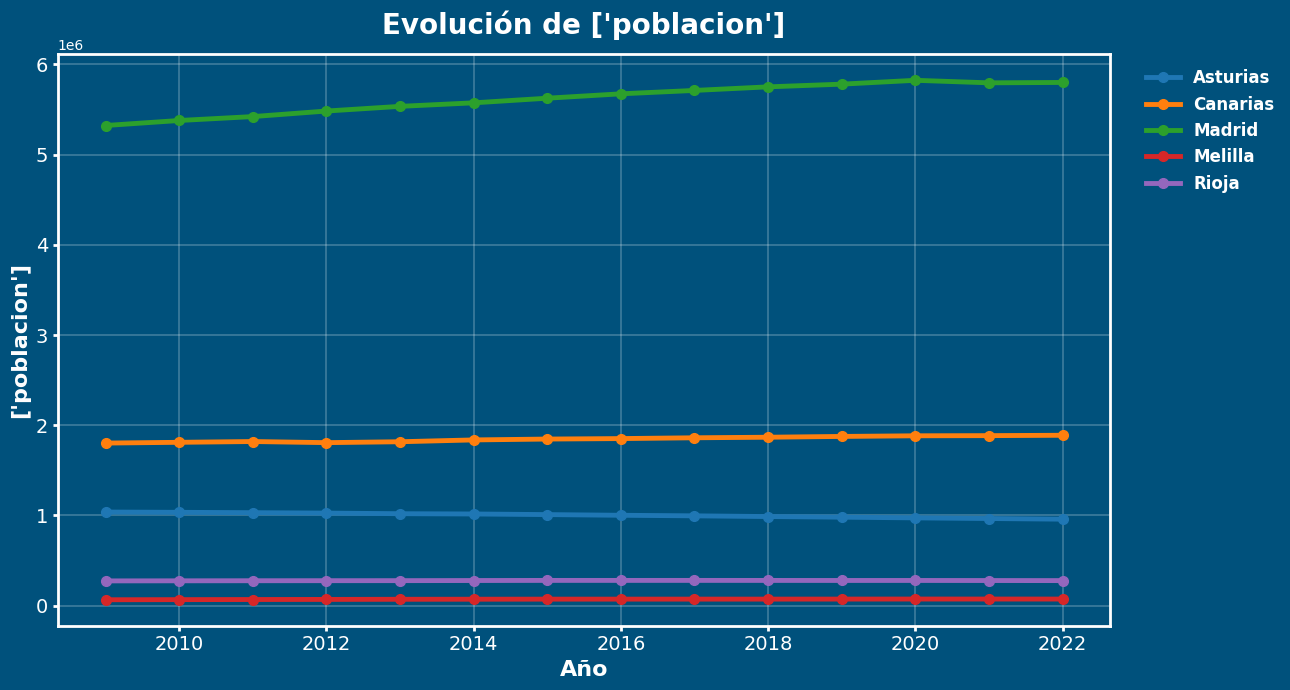

In [31]:
ut.plot_todas_comunidades(df, ['poblacion'], ['Asturias', 'Canarias', 'Madrid', 'Melilla', 'Rioja']);

*Con la información proporcionada por esta gráfica vemos que la población es una serie con una varianza mayor a lo largo de los años, en comunidades como Madrid tiene una clara tendencia ascendente, sin embargo, en Asturias este tendencia es claramente descendente, aunque en cualquier caso son valores relativamente constantes, que nos permiten amortiguar la diferencia de PIB bruto por comunidad para tomar la gráfica anterior como un buen valor de referencia.*

In [32]:
for comunidad, datos in corr_matrices.items():
    print(comunidad, '----', datos.loc['año', 'poblacion'])

Andalucía ---- 0.8433097623217969
Aragón ---- -0.7321427517541022
Asturias ---- -0.9943299259971858
Balears ---- 0.9908887046004146
Canarias ---- 0.9807829731434297
Cantabria ---- -0.8114451077000943
Castilla - La Mancha ---- -0.4835986018474175
Castilla Y León ---- -0.9939713280798625
Cataluña ---- 0.9313814714847053
Ceuta ---- 0.5773895533390876
Comunitat Valenciana ---- 0.965446364826127
Extremadura ---- -0.9575439120284602
Galicia ---- -0.9967838600429156
Madrid ---- 0.9786882430327865
Melilla ---- 0.9117762239184759
Murcia ---- 0.998075379866932
Navarra ---- 0.937760960680802
País Vasco ---- -0.273248481959851
Rioja ---- 0.7081587572462942


#### Existe una correlación positiva entre PIB y Año

* En todas las comunidades se observa un crecimiento más o menos regular del PIB a lo largo de los años.
* Existe un año en que todas ellas reducen su PIB, en 2020, año donde estalló la pandemia y paró durante meses el funcionamiento normal del país.
* Durante el resto de datos no existen reducciones de PIB ya que coinciden con todos los años posteriores a la crisis del ladrillo de 2008, donde el país se encuentra en una paulatina y lenta recuperación.
* Comunidades más grandes son capaces de aumentar más su PIB y seguir desarrollandose, aumentando su población, con el ejemplo de Madrid.
* Comunidades más pequeñas tienen más problemas para aumentar su PIB, perdiendo población a lo largo del tiempo como Asturias.
* La tendencia del PIB per Cápita es muy similar en todas ellas, donde el PIB crece más rápido lo hace a costa de un aumento de población. Donde el PIB crece más lento existe una pérdida de población.
* Existen grandes desigualdades en PIB per Cápita para las distintas comunidades autónomas.
* Existen fuertes tendencias positivas o negativas en la población en cada comunidad autónoma, lo que indica un futuro problema social, aumentando la centralización de la población y las zonas vaciadas.

## Tasa de Natalidad - Renta PC

Con los resultados obtenidos en la anterior tabla se verifica que existe una alta correlación positiva entre la renta per cápita y la tasa de natalidad, de modo que a medida que aumenta la renta per cápita la tasa de natalidad disminuye de con una fuerte tendencia negativa. Para verificar esto, haremos un análisis más en profundidad de estas dos variables, desgranando por cada comunidad y buscando aquellos valores más representativos.

In [33]:
ut.correlacion_com_bivariante(df, df.comunidad_autonoma.unique(), 'tasa_natalidad', 'renta_pc',alpha = 0.05)

Coeficiente de correlación de Spearman entre tasa_natalidad y renta_pc

Comunidades con correlacion positiva y sus coeficientes (pval < 0.05 y coef > 0):
 []
 []


Comunidades con correlacion negativa y sus coeficientes (pval < 0.05 y coef < 0):
 ['Andalucía', 'Aragón', 'Asturias', 'Balears', 'Canarias', 'Cantabria', 'Castilla - La Mancha', 'Castilla Y León', 'Cataluña', 'Ceuta', 'Comunitat Valenciana', 'Extremadura', 'Galicia', 'Madrid', 'Melilla', 'Murcia', 'Navarra', 'País Vasco', 'Rioja']
 [-0.746, -0.785, -0.815, -0.749, -0.732, -0.789, -0.833, -0.837, -0.846, -0.591, -0.824, -0.824, -0.862, -0.873, -0.859, -0.82, -0.626, -0.767, -0.877]


Comunidades sin correlacion y sus coeficientes (pval < 0.05 y coef ≈ 0):
 []
 []


Comunidades que no se encontró evidencia estadísticamente significativa y su pval (pval > 0.05):
 []
 []


Rechazamos la hipótesis nula y se verifica la hipótesis alternativa donde indica que al aumenta de al tasa de natalidad, la renta PC disminuye.

In [34]:
for comunidad, datos in corr_matrices.items():
    print(comunidad, '|', datos.loc['tasa_natalidad', 'renta_pc'], '|', p_matrices[comunidad].loc['año', 'pib_total'])

Andalucía | -0.8035208312932565 | 0.0006513873376028277
Aragón | -0.8367507731474243 | 0.0005134958502300675
Asturias | -0.8274035681703591 | 0.03945967166231658
Balears | -0.6880547244847626 | 0.002490774207798018
Canarias | -0.7431785004764394 | 0.01943544291848523
Cantabria | -0.8162998077239472 | 0.0023638262634118564
Castilla - La Mancha | -0.8240691424317843 | 0.0034279753042490762
Castilla Y León | -0.8793112027235326 | 0.004034364897704507
Cataluña | -0.7778776175547469 | 0.00011827526559966788
Ceuta | -0.7780136963587512 | 0.0004483842070766643
Comunitat Valenciana | -0.8104816726862546 | 0.0005342080672554936
Extremadura | -0.890405804160395 | 0.00027422512245951194
Galicia | -0.9029882008782233 | 0.00035240090746974827
Madrid | -0.8531403281191056 | 3.384406744437442e-05
Melilla | -0.8858793970085116 | 5.1097404876979466e-05
Murcia | -0.8125261449983286 | 9.295051237360638e-05
Navarra | -0.6694751631562045 | 0.00018269107434038784
País Vasco | -0.8632035135347634 | 0.0002977

*Para representar en una gráfica los valores de mayor interés seleccionaremos aquellos con mayor correlación (Galicia y Extremadura), aquellos con menor (Baleares y Navarra) y uno intermedio (Canarias) para tener una idea aproximada del conjunto de valores.*

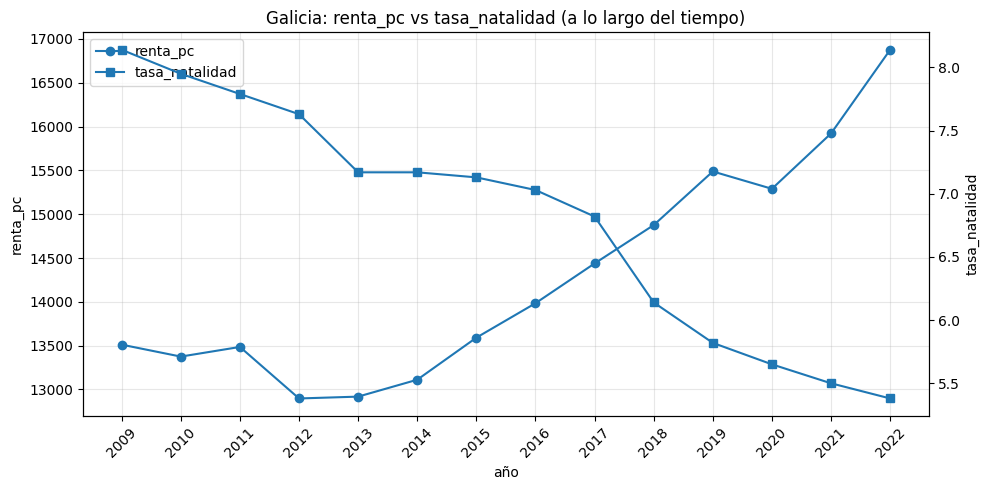

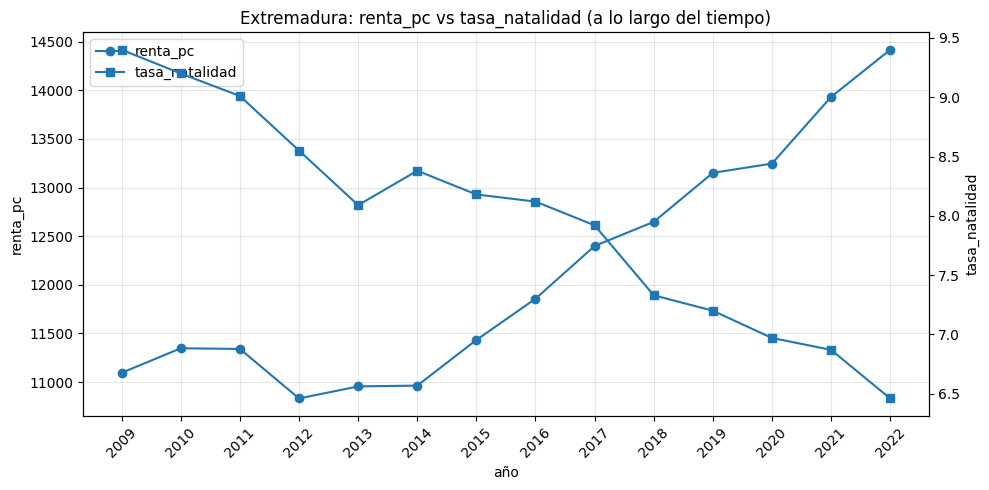

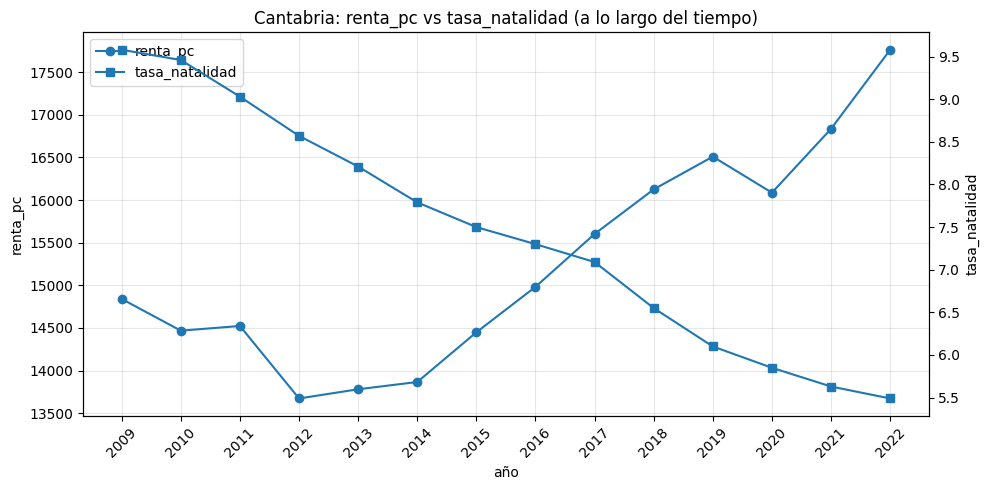

In [35]:
ut.plot_dual_axis(df, ['Galicia', 'Extremadura', 'Cantabria'], 'renta_pc', 'tasa_natalidad');

*Podemos observar que en todas las comunidades analizadas el comportamiento de ambas variables es similar, la renta per cápita aumenta a lo largo del tiempo, mientras que la tasa de natalidad disminuye a lo largo del tiempo. Para continuar con el análisas vamos a coger aquellas comunidades donde la renta per cápita y tasa de natalidad tengan mayor variación a lo largo del tiempo.*

In [36]:
ut.correlacion_com_bivariante(df, df.comunidad_autonoma.unique(), 'tasa_natalidad', 'año',alpha = 0.1)

Coeficiente de correlación de Spearman entre tasa_natalidad y año

Comunidades con correlacion positiva y sus coeficientes (pval < 0.1 y coef > 0):
 []
 []


Comunidades con correlacion negativa y sus coeficientes (pval < 0.1 y coef < 0):
 ['Andalucía', 'Aragón', 'Asturias', 'Balears', 'Canarias', 'Cantabria', 'Castilla - La Mancha', 'Castilla Y León', 'Cataluña', 'Ceuta', 'Comunitat Valenciana', 'Extremadura', 'Galicia', 'Madrid', 'Melilla', 'Murcia', 'Navarra', 'País Vasco', 'Rioja']
 [-0.995, -0.996, -0.982, -0.991, -0.974, -1.0, -1.0, -0.987, -0.996, -0.956, -0.996, -0.974, -0.999, -0.996, -0.776, -0.991, -0.991, -0.982, -0.987]


Comunidades sin correlacion y sus coeficientes (pval < 0.1 y coef ≈ 0):
 []
 []


Comunidades que no se encontró evidencia estadísticamente significativa y su pval (pval > 0.1):
 []
 []


In [37]:
ut.correlacion_com_bivariante(df, df.comunidad_autonoma.unique(), 'año', 'renta_pc',alpha = 0.1)

Coeficiente de correlación de Spearman entre año y renta_pc

Comunidades con correlacion positiva y sus coeficientes (pval < 0.1 y coef > 0):
 ['Andalucía', 'Aragón', 'Asturias', 'Balears', 'Canarias', 'Cantabria', 'Castilla - La Mancha', 'Castilla Y León', 'Cataluña', 'Ceuta', 'Comunitat Valenciana', 'Extremadura', 'Galicia', 'Madrid', 'Melilla', 'Murcia', 'Navarra', 'País Vasco', 'Rioja']
 [0.754, 0.793, 0.851, 0.771, 0.763, 0.789, 0.833, 0.842, 0.851, 0.574, 0.833, 0.877, 0.864, 0.877, 0.547, 0.82, 0.644, 0.767, 0.855]


Comunidades con correlacion negativa y sus coeficientes (pval < 0.1 y coef < 0):
 []
 []


Comunidades sin correlacion y sus coeficientes (pval < 0.1 y coef ≈ 0):
 []
 []


Comunidades que no se encontró evidencia estadísticamente significativa y su pval (pval > 0.1):
 []
 []


In [38]:
for comunidad, datos in corr_matrices.items():
    print(comunidad, '|', datos.loc['tasa_natalidad', 'año'])

Andalucía | -0.9923566124977441
Aragón | -0.986056681159109
Asturias | -0.9815477454376761
Balears | -0.9828739751162408
Canarias | -0.9808413812512093
Cantabria | -0.9961738920272519
Castilla - La Mancha | -0.9912956048860664
Castilla Y León | -0.9909410819677467
Cataluña | -0.9919571252660967
Ceuta | -0.9546236733689005
Comunitat Valenciana | -0.9912278512604445
Extremadura | -0.9811155464451511
Galicia | -0.9816396517401225
Madrid | -0.9917153155742461
Melilla | -0.835753450035615
Murcia | -0.9912970389109206
Navarra | -0.9858579118456168
País Vasco | -0.9806270763147811
Rioja | -0.9889033308889879


In [39]:
for comunidad, datos in corr_matrices.items():
    print(comunidad, '|', datos.loc['renta_pc', 'año'])

Andalucía | 0.8304521142414583
Aragón | 0.8364203384933911
Asturias | 0.8637843640884286
Balears | 0.7674893969284696
Canarias | 0.7964922152142008
Cantabria | 0.8433288215814632
Castilla - La Mancha | 0.8738945843022566
Castilla Y León | 0.8786700570712764
Cataluña | 0.8272019386027812
Ceuta | 0.6817975953446698
Comunitat Valenciana | 0.8524021930919217
Extremadura | 0.9134463874105644
Galicia | 0.891045888080357
Madrid | 0.8706608852239655
Melilla | 0.6274558588173966
Murcia | 0.8418428466550589
Navarra | 0.6568478812927784
País Vasco | 0.803000009390614
Rioja | 0.859670622213775


*Con los resultados mostrados en al anterior tabla no parece que haya ninguna diferencia entre las correlaciones de tasa de natalidad y año, tan solo Melilla muestra un dato algo más dispar, pero conocemos que es un dato con una muestra muy pequeña y con fuerte influencia por fenómenos puntuales. En cuanto a la renta per cápita se ven valores con mayor variación. No consideramos que ninguna de las comunidades puedan aportarnos mayor información en este aspecto.*

*Por otro lado existe una correlación positiva entre la tasa de natalidad y la dificultad para llegar a fin de mes. Vamos a comprobar estos valores con la matriz de correlación.*

In [40]:
ut.correlacion_com_bivariante(df, df.comunidad_autonoma.unique(), 'tasa_natalidad', 'dificultad_fin_mes', alpha = 0.1)

Coeficiente de correlación de Spearman entre tasa_natalidad y dificultad_fin_mes

Comunidades con correlacion positiva y sus coeficientes (pval < 0.1 y coef > 0):
 ['Andalucía', 'Asturias', 'Balears', 'Canarias', 'Castilla - La Mancha', 'Castilla Y León', 'Cataluña', 'Ceuta', 'Comunitat Valenciana', 'Extremadura', 'Galicia', 'Madrid', 'Melilla', 'Murcia', 'País Vasco', 'Rioja']
 [0.684, 0.604, 0.547, 0.745, 0.547, 0.824, 0.807, 0.793, 0.647, 0.56, 0.783, 0.727, 0.71, 0.727, 0.785, 0.807]


Comunidades con correlacion negativa y sus coeficientes (pval < 0.1 y coef < 0):
 []
 []


Comunidades sin correlacion y sus coeficientes (pval < 0.1 y coef ≈ 0):
 []
 []


Comunidades que no se encontró evidencia estadísticamente significativa y su pval (pval > 0.1):
 ['Aragón', 'Cantabria', 'Navarra']
 [0.215, 0.154, 0.22]


In [41]:
for comunidad, datos in corr_matrices.items():
    print(comunidad, '----', datos.loc['tasa_natalidad', 'dificultad_fin_mes'])

Andalucía ---- 0.7611665512795188
Aragón ---- 0.39423624595119033
Asturias ---- 0.5735282601935658
Balears ---- 0.5692851818391524
Canarias ---- 0.6963634362501314
Cantabria ---- 0.42291614140803446
Castilla - La Mancha ---- 0.5882537869689213
Castilla Y León ---- 0.863420655549095
Cataluña ---- 0.7893981190358861
Ceuta ---- 0.8061365544602401
Comunitat Valenciana ---- 0.6473560664802592
Extremadura ---- 0.537861099311398
Galicia ---- 0.8182839209769927
Madrid ---- 0.817847889885185
Melilla ---- 0.6217823586645285
Murcia ---- 0.7895598643180071
Navarra ---- 0.28149653750072046
País Vasco ---- 0.7265287794579511
Rioja ---- 0.8215829914795216


*Para representar en una gráfica los valores de mayor interés seleccionaremos aquellos con mayor correlación (Castilla y León y Rioja), aquellos con menor (Navarra y Aragón) y uno intermedio (Comunidad Valenciana) para tener una idea aproximada del conjunto de valores.*

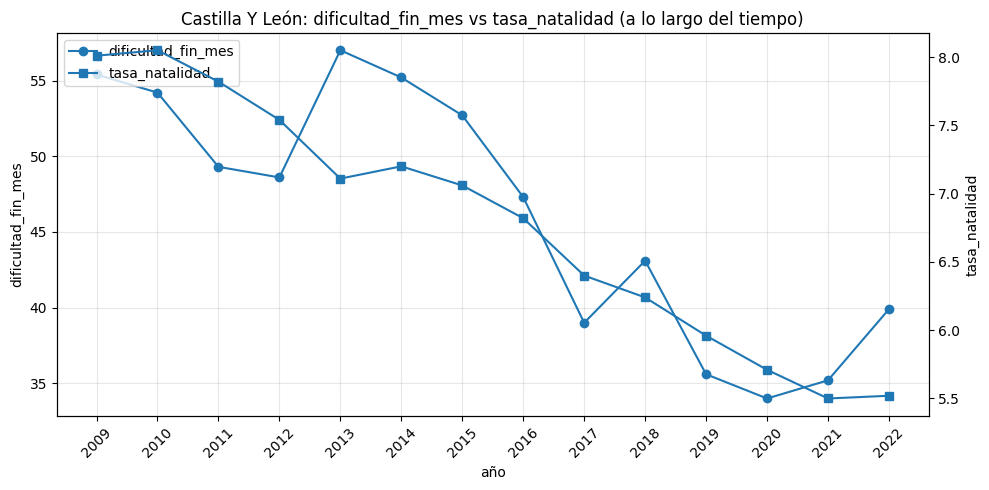

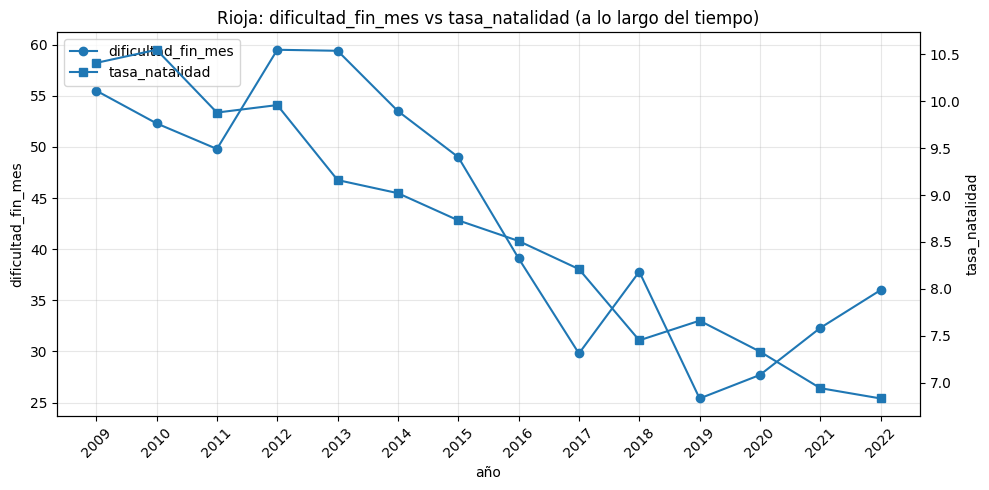

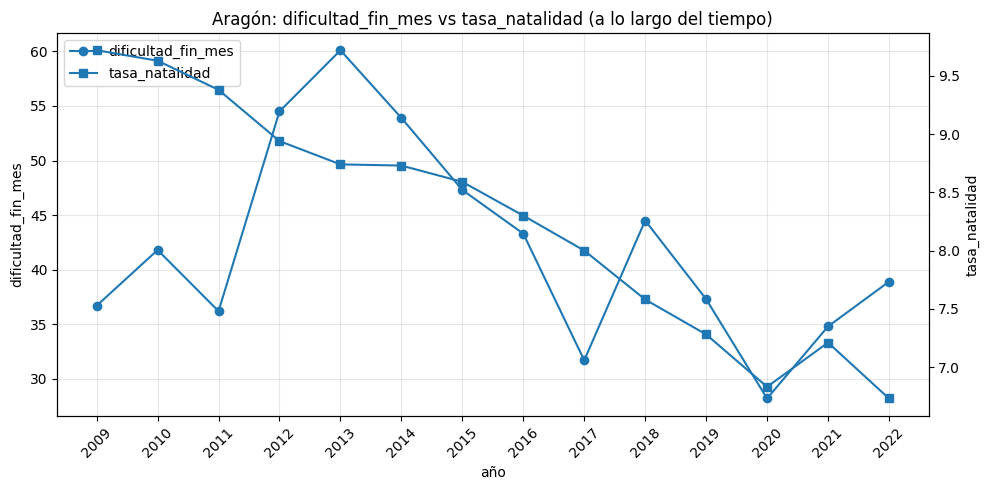

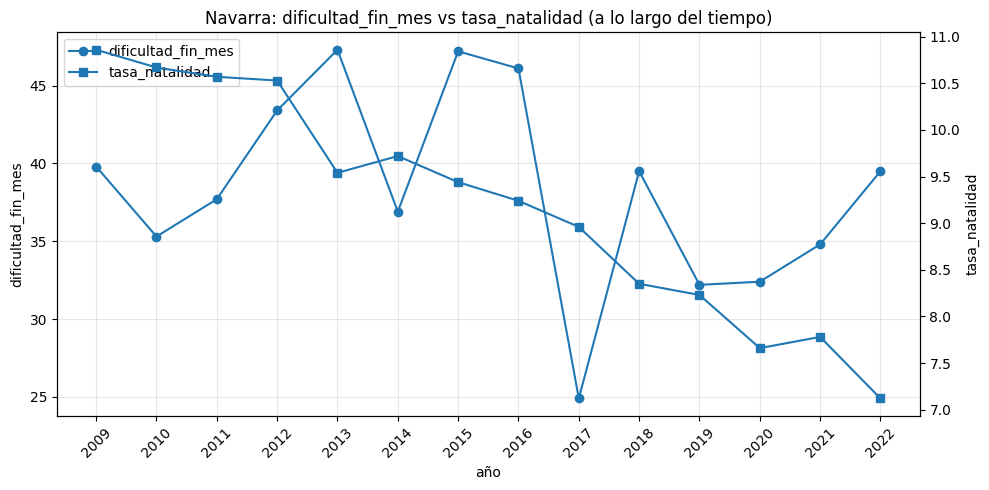

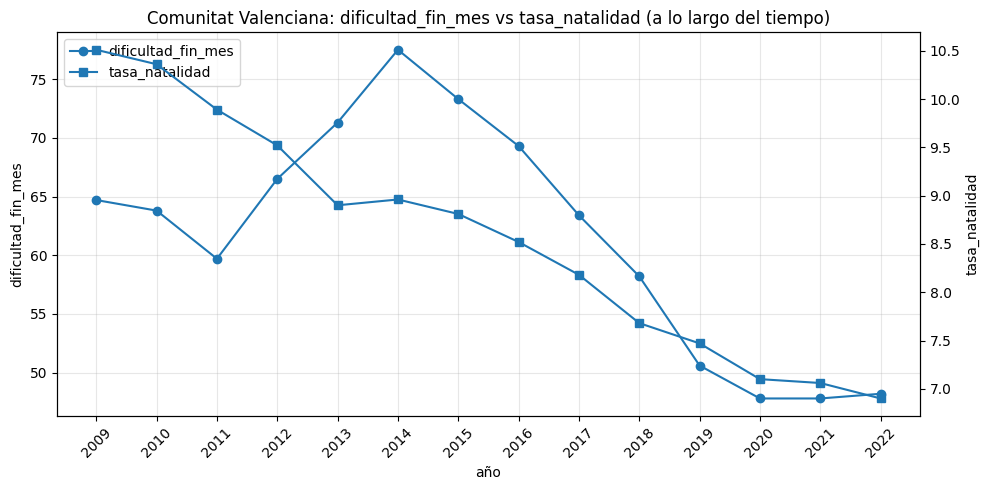

In [42]:
ut.plot_dual_axis(df, ['Castilla Y León', 'Rioja', 'Aragón', 'Navarra', 'Comunitat Valenciana'], 'dificultad_fin_mes', 'tasa_natalidad');

*Como en los resultados anteriores se observa que la tasa de natalidad tan solo decrece, mientras que en la dificultad para llegar a fin de mes, aunque tenga tendencia negativa, no tiene una inclinación tan estable a lo largo del tiempo.*

#### Existe una correlación negativa entre Tasa de Natalidad y Año, Renta per Cápita y positiva con la dificultad a fin de mes

* Existe una muy fuerte correlación negativa entre la tasa de Natalidad y Año.
* Existe una muy fuerte correlación positiva entre la Renta per Cápita y Año.
* Existe una muy fuerte correlación entre la Dificultad para llegar a fin de mes y Año.
* Estas correlaciónes con los años puede influir a las existentes entre tasa de natalidad, renta per cápita y dificultad para llegar a fin de mes, sin embargo, tratemos de buscar una explicación para estos altos valores de correlación.
* La renta per cápita viene influida por el número de habitantes, por lo que el aumento de población debido a la natalidad podría provocar que esta automaticamente se viera reducida.
* La dificultad para llegar a fin de mes esta impuesta por las responsabilidades de cada individuo, siendo la crianza una de las mayores, si la natalidad decrece la capacidad para llegar a fin de mes se ve aumentada.
* Definitivamente la variación tasa de natalidad está muy ligada al tiempo, esto nos hace pensar que todas las variantes que tengan una fuerte relación con el tiempo pueden verse reflejadas también con la tasa de natalidad.
* A partir de aquí vamos a buscar otros pares de variables donde el tiempo no este tan fuertemente correlacionado para ver otro tipo de comparativas.

Para cada par de variables encontrado en la gráfica.

Correlación - Rechazar la hipótesis nula - Graficar cruce de variables en comunidades relevantes (correlación alta, baja y media) - Escribir conclusiones por cada pares de variables>

## Riesgo de pobreza - Paro / Desigualdad de ingresos / Precio alquiler

Con los resultados obtenidos en la anterior tabla se verifica que existe una alta correlación positiva entre el riesgo de pobreza y las variables Paro, Desigualdad de ingresos y Precio alquiler. Para verificar esto, haremos un análisis más en profundidad de estas variables, desgranando por cada comunidad y buscando aquellos valores más representativos.

In [43]:
ut.correlacion_com_bivariante(df, df.comunidad_autonoma.unique(), 'riesgo_pobreza', 'paro',alpha = 0.05)

Coeficiente de correlación de Spearman entre riesgo_pobreza y paro

Comunidades con correlacion positiva y sus coeficientes (pval < 0.05 y coef > 0):
 ['Andalucía', 'Aragón', 'Balears', 'Canarias', 'Cantabria', 'Castilla - La Mancha', 'Castilla Y León', 'Cataluña', 'Comunitat Valenciana', 'Extremadura', 'Galicia', 'Madrid', 'Murcia', 'Navarra', 'País Vasco', 'Rioja']
 [0.881, 0.705, 0.789, 0.783, 0.867, 0.943, 0.912, 0.711, 0.736, 0.9, 0.835, 0.675, 0.815, 0.859, 0.616, 0.642]


Comunidades con correlacion negativa y sus coeficientes (pval < 0.05 y coef < 0):
 []
 []


Comunidades sin correlacion y sus coeficientes (pval < 0.05 y coef ≈ 0):
 []
 []


Comunidades que no se encontró evidencia estadísticamente significativa y su pval (pval > 0.05):
 ['Asturias', 'Ceuta', 'Melilla']
 [0.083, 0.154, 0.703]


Rechazamos la hipótesis nula y se verifica la hipótesis alternativa donde indica que al aumenta de al tasa de natalidad, la renta PC disminuye.

In [44]:
for comunidad, datos in corr_matrices.items():
    print(comunidad, '|', datos.loc['riesgo_pobreza', 'paro'])

Andalucía | 0.8609104384192384
Aragón | 0.7529840921326474
Asturias | 0.5875404577725112
Balears | 0.7956437353098246
Canarias | 0.7042742164540533
Cantabria | 0.866777128427359
Castilla - La Mancha | 0.9578543559189631
Castilla Y León | 0.9115442091658484
Cataluña | 0.7756146353982398
Ceuta | 0.4983529834076554
Comunitat Valenciana | 0.7502338336233245
Extremadura | 0.8839217954063737
Galicia | 0.8030073926056683
Madrid | 0.7076022885598482
Melilla | -0.00548639269379492
Murcia | 0.7816022788524243
Navarra | 0.85514323568071
País Vasco | 0.5019654543322958
Rioja | 0.7974198428231762


*Para representar en una gráfica los valores de mayor interés seleccionaremos aquellos con mayor correlación (Castilla - La Mancha y Castilla Y León), aquellos con menor (Melilla y Ceuta) y uno intermedio (Cataluña) para tener una idea aproximada del conjunto de valores.*

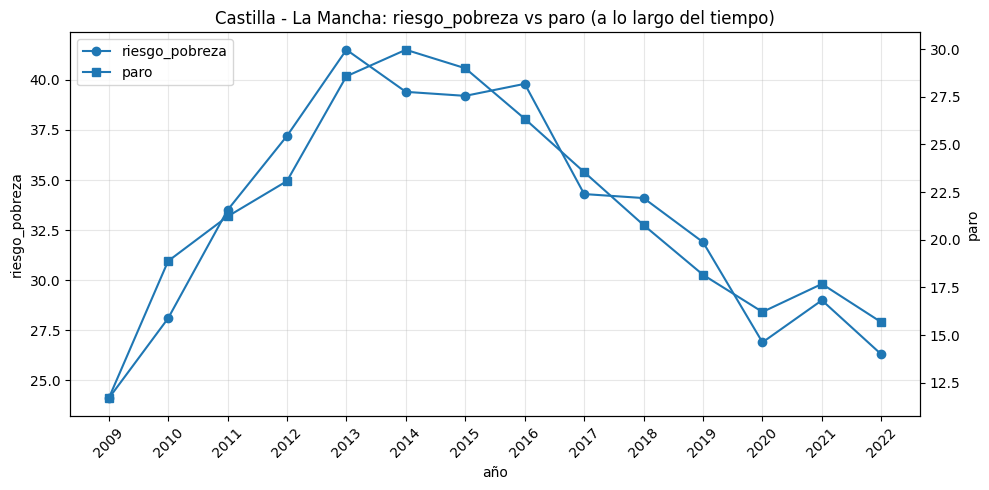

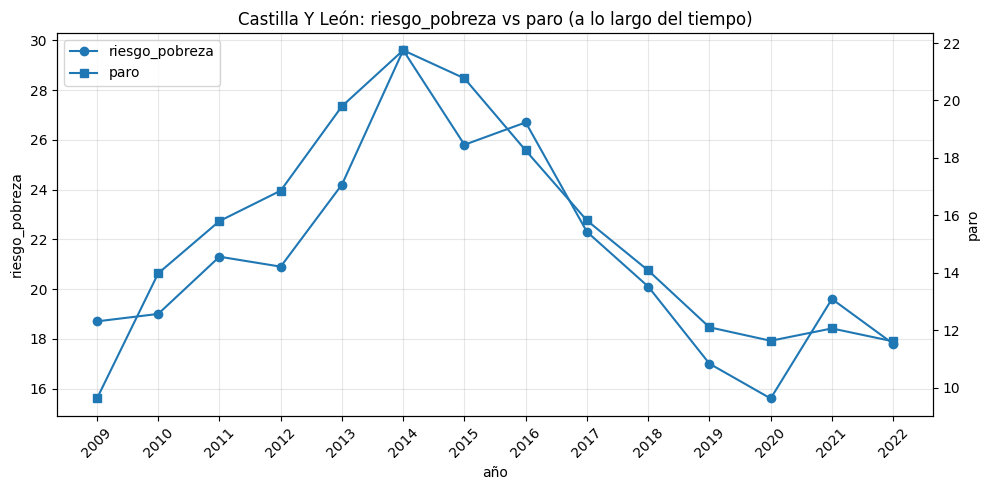

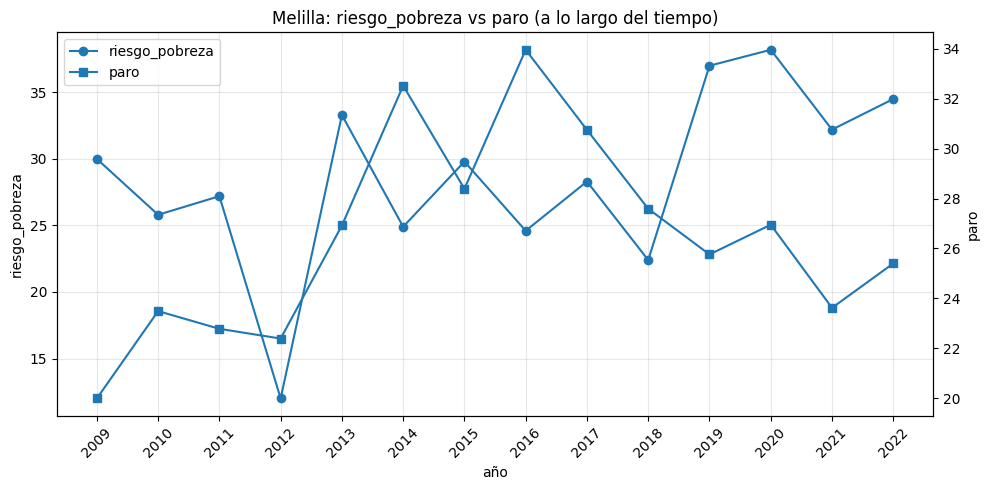

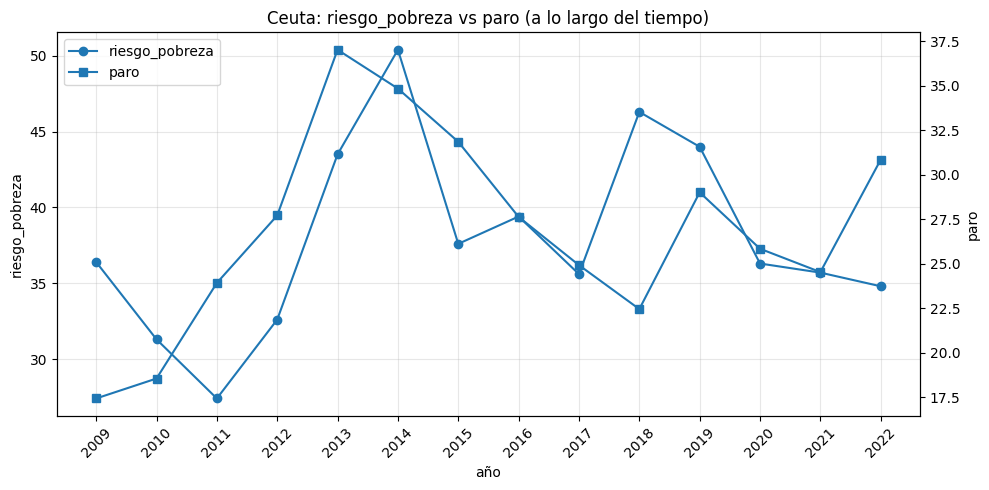

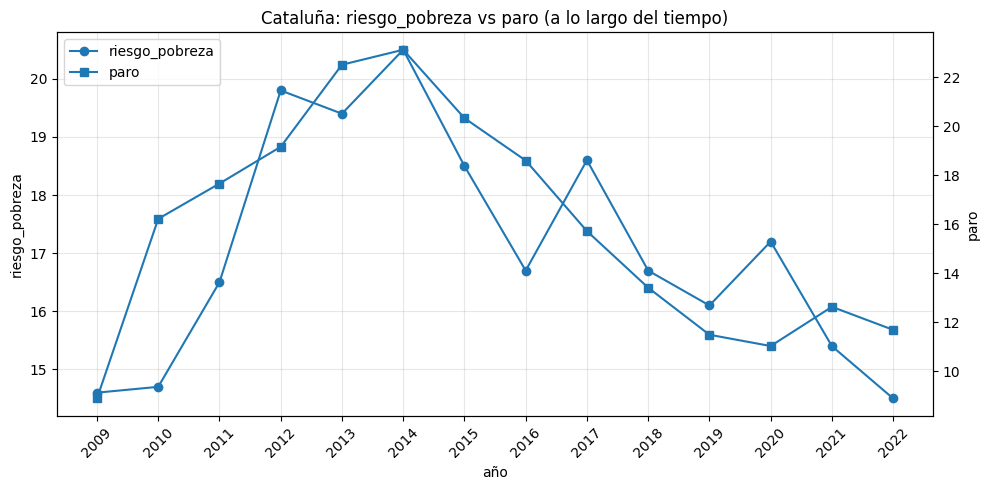

In [45]:
ut.plot_dual_axis(df, ['Castilla - La Mancha', 'Castilla Y León', 'Melilla', 'Ceuta', 'Cataluña'], 'riesgo_pobreza', 'paro');

*Podemos observar que en todas las comunidades analizadas el comportamiento de ambas variables es similar, las variables se comportan con correlación positiva. En las comunidades donde este fenómeno se ve menos representado son en Ceuta y Melilla donde la muestra es más pequeña y las variaciones pueden provocar grandes alteraciones.*

In [46]:
ut.correlacion_com_bivariante(df, df.comunidad_autonoma.unique(), 'riesgo_pobreza', 'desigualdad_ing(S80/S20)',alpha = 0.1)

Coeficiente de correlación de Spearman entre riesgo_pobreza y desigualdad_ing(S80/S20)

Comunidades con correlacion positiva y sus coeficientes (pval < 0.1 y coef > 0):
 ['Andalucía', 'Aragón', 'Asturias', 'Balears', 'Canarias', 'Castilla - La Mancha', 'Castilla Y León', 'Cataluña', 'Extremadura', 'Galicia', 'Madrid', 'Melilla', 'Murcia', 'País Vasco', 'Rioja']
 [0.67, 0.741, 0.73, 0.904, 0.729, 0.797, 0.62, 0.567, 0.462, 0.488, 0.768, 0.717, 0.634, 0.466, 0.878]


Comunidades con correlacion negativa y sus coeficientes (pval < 0.1 y coef < 0):
 []
 []


Comunidades sin correlacion y sus coeficientes (pval < 0.1 y coef ≈ 0):
 []
 []


Comunidades que no se encontró evidencia estadísticamente significativa y su pval (pval > 0.1):
 ['Cantabria', 'Ceuta', 'Comunitat Valenciana', 'Navarra']
 [0.186, 0.881, 0.265, 0.306]


Rechazamos la hipótesis nula y se verifica la hipótesis alternativa donde indica que al aumenta de al tasa de natalidad, la renta PC disminuye.

In [47]:
for comunidad, datos in corr_matrices.items():
    print(comunidad, '|', datos.loc['riesgo_pobreza', 'desigualdad_ing(S80/S20)'])

Andalucía | 0.7081967948862206
Aragón | 0.7375561484492091
Asturias | 0.6462446855554992
Balears | 0.8897605178927417
Canarias | 0.5454286130608921
Cantabria | -0.23908178583305853
Castilla - La Mancha | 0.8645451557530697
Castilla Y León | 0.7949943430953765
Cataluña | 0.5523146896922275
Ceuta | 0.08415378017153322
Comunitat Valenciana | 0.3891305148670707
Extremadura | 0.3789187625415271
Galicia | 0.536379514253733
Madrid | 0.7432598351970641
Melilla | 0.7966231516650563
Murcia | 0.6390715161151125
Navarra | 0.28429624741659115
País Vasco | 0.6639014154054712
Rioja | 0.9032315008270226


*Para representar en una gráfica los valores de mayor interés seleccionaremos aquellos con mayor correlación (Rioja y Balears), aquellos con menor (Cantabria y Ceuta) y uno intermedio (País Vasco) para tener una idea aproximada del conjunto de valores.*

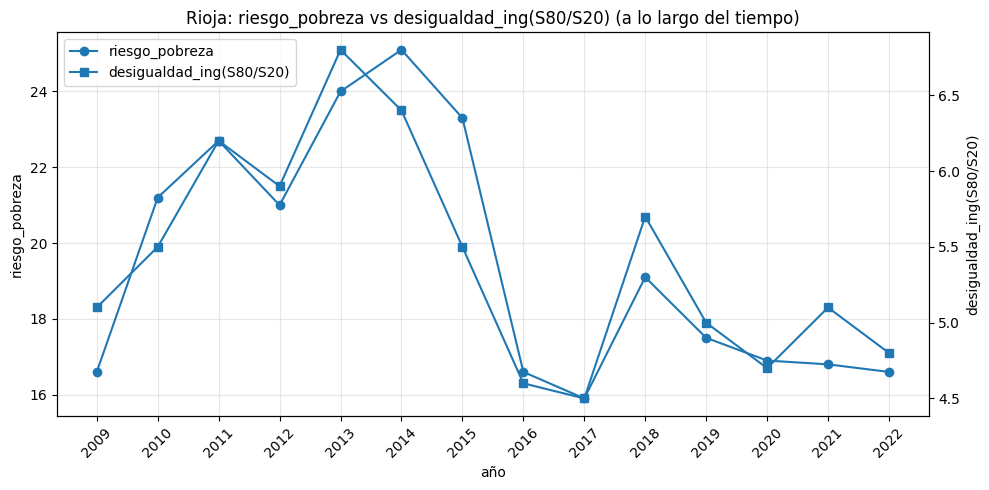

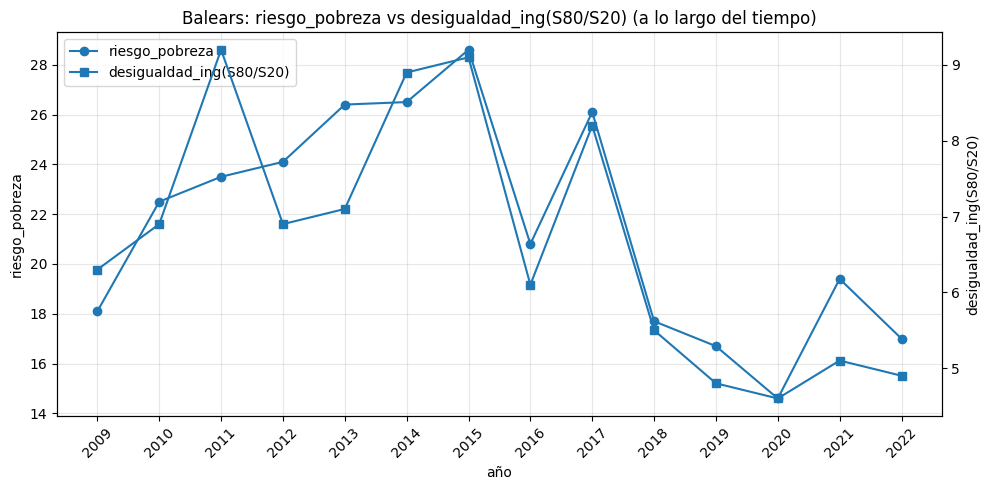

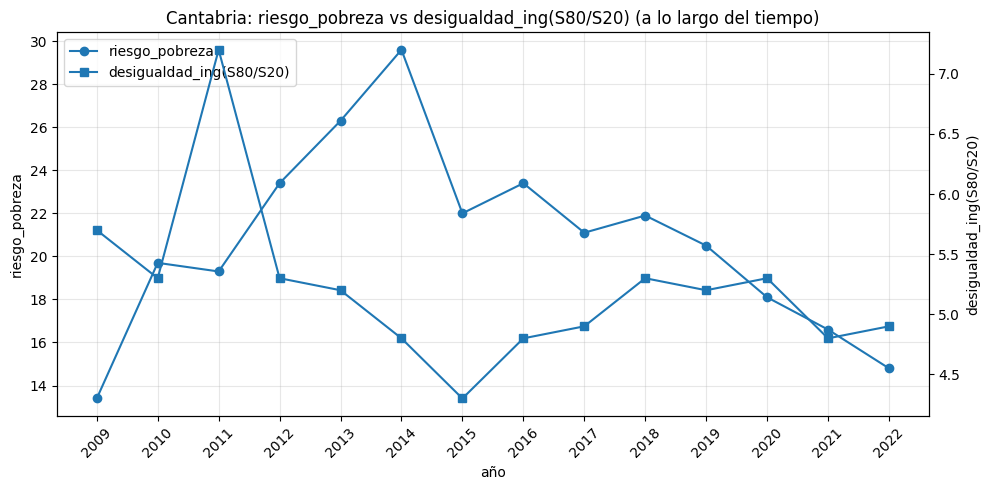

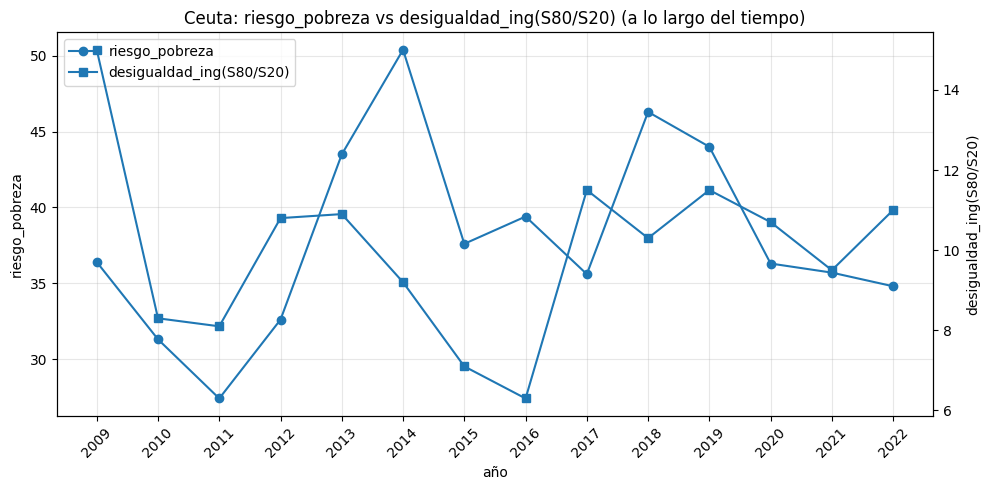

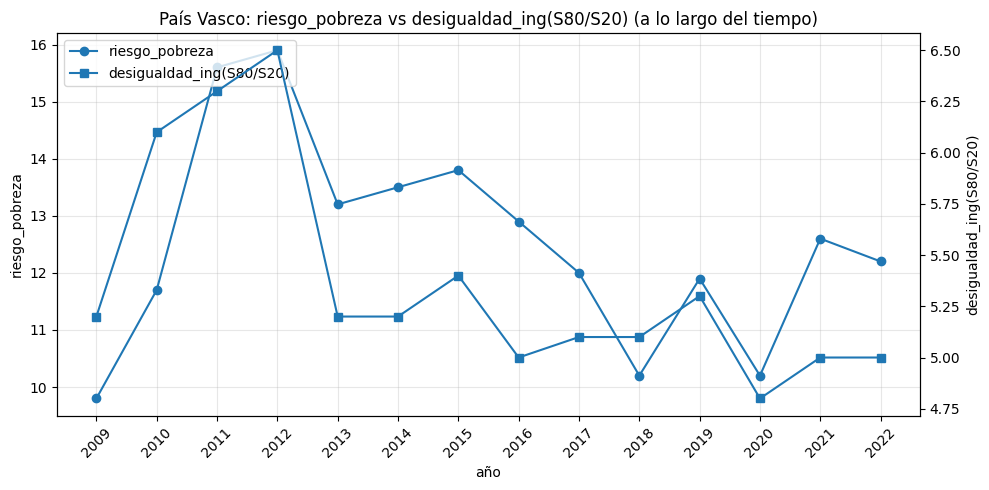

In [48]:
ut.plot_dual_axis(df, ['Rioja', 'Balears', 'Cantabria', 'Ceuta', 'País Vasco'], 'riesgo_pobreza', 'desigualdad_ing(S80/S20)');

*Podemos observar que en todas las comunidades analizadas el comportamiento de ambas variables es similar, las variables se comportan con correlación positiva. En las comunidades donde este fenómeno se ve menos representado son en Ceuta y Cantabria donde la muestra es más pequeña y las variaciones pueden provocar grandes alteraciones.*

In [49]:
ut.correlacion_com_bivariante(df, df.comunidad_autonoma.unique(), 'riesgo_pobreza', 'precio_alquiler_m2',alpha = 0.1)

Coeficiente de correlación de Spearman entre riesgo_pobreza y precio_alquiler_m2

Comunidades con correlacion positiva y sus coeficientes (pval < 0.1 y coef > 0):
 []
 []


Comunidades con correlacion negativa y sus coeficientes (pval < 0.1 y coef < 0):
 ['Andalucía', 'Aragón', 'Asturias', 'Balears', 'Canarias', 'Cantabria', 'Castilla - La Mancha', 'Castilla Y León', 'Cataluña', 'Comunitat Valenciana', 'Extremadura', 'Galicia', 'Murcia']
 [-0.719, -0.644, -0.469, -0.829, -0.697, -0.909, -0.846, -0.666, -0.532, -0.745, -0.871, -0.802, -0.881]


Comunidades sin correlacion y sus coeficientes (pval < 0.1 y coef ≈ 0):
 []
 []


Comunidades que no se encontró evidencia estadísticamente significativa y su pval (pval > 0.1):
 ['Ceuta', 'Madrid', 'Melilla', 'Navarra', 'País Vasco', 'Rioja']
 [0.269, 0.302, 0.618, 0.12, 0.242, 0.144]


In [50]:
for comunidad, datos in corr_matrices.items():
    print(comunidad, '|', datos.loc['riesgo_pobreza', 'precio_alquiler_m2'])

Andalucía | -0.6439185530625268
Aragón | -0.6379799011116307
Asturias | -0.5470233667896564
Balears | -0.7884828930921525
Canarias | -0.6209656209615809
Cantabria | -0.8942251271045318
Castilla - La Mancha | -0.8039542341725221
Castilla Y León | -0.6718560474376009
Cataluña | -0.4491249194546179
Ceuta | -0.3779236540523459
Comunitat Valenciana | -0.6438009712008509
Extremadura | -0.8846701208650831
Galicia | -0.793486242377095
Madrid | -0.3548243184067739
Melilla | -0.08868527323953054
Murcia | -0.8227834990201497
Navarra | -0.331501094488574
País Vasco | -0.22514701594264525
Rioja | -0.5215052784980713


*Para representar en una gráfica los valores de mayor interés seleccionaremos aquellos con mayor correlación (Extremadura y Cantabria), aquellos con menor (Melilla y Ceuta) y uno intermedio (Comunitat Valenciana) para tener una idea aproximada del conjunto de valores.*

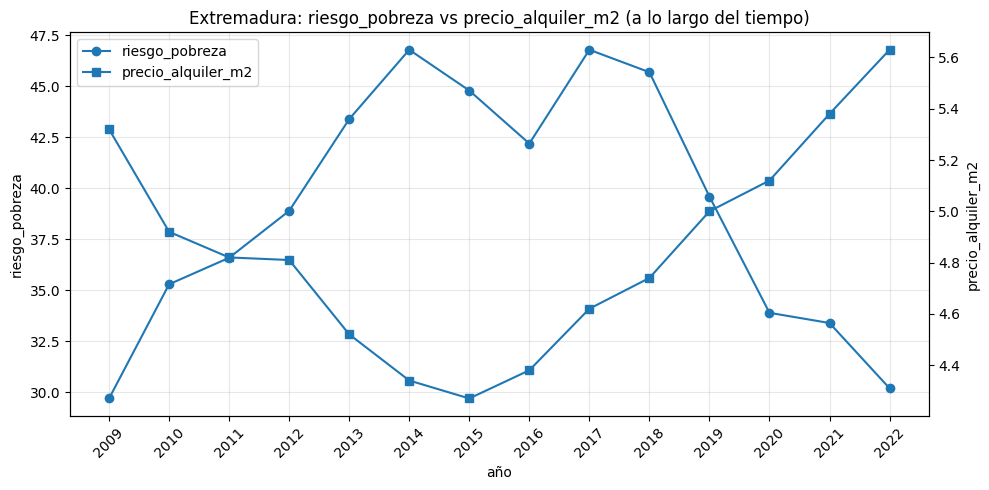

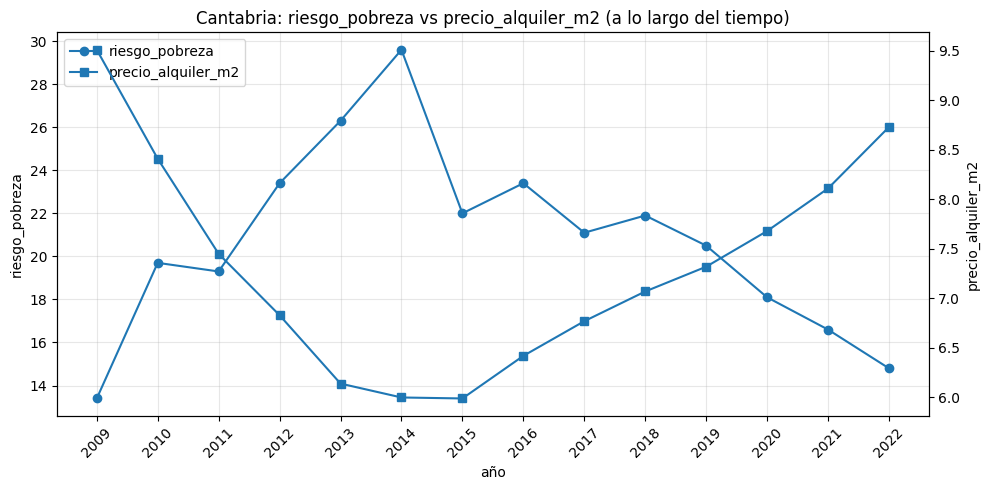

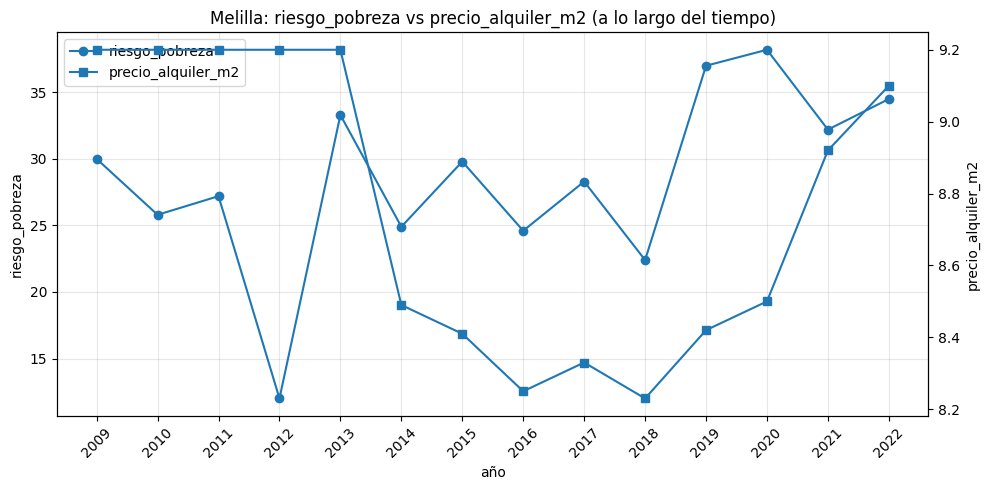

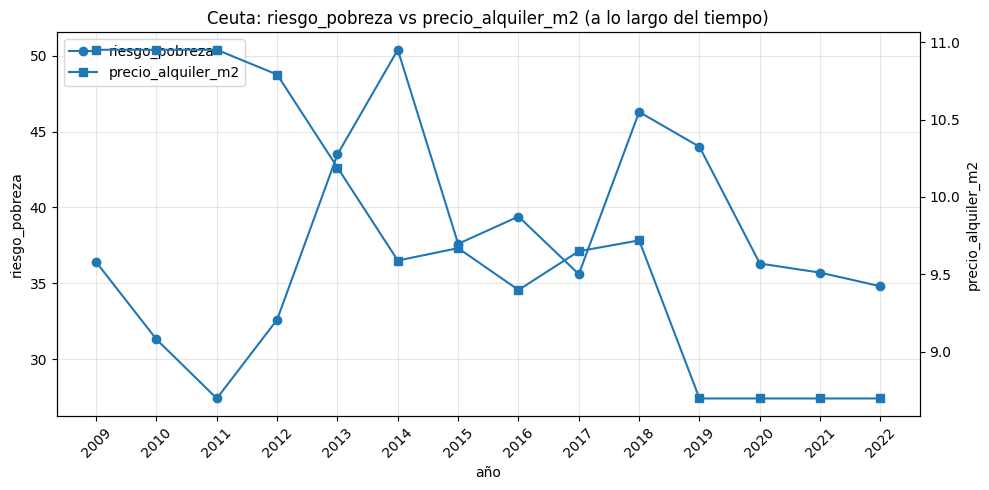

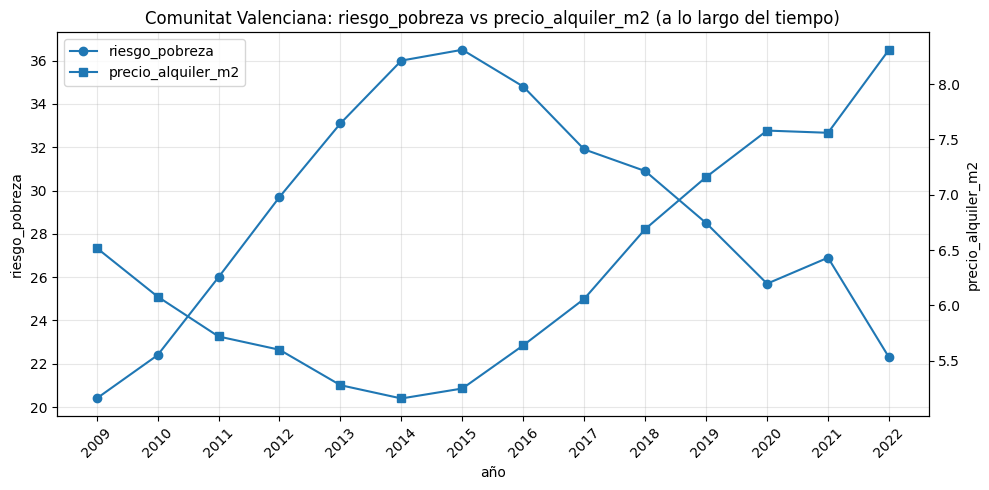

In [51]:
ut.plot_dual_axis(df, ['Extremadura', 'Cantabria', 'Melilla', 'Ceuta', 'Comunitat Valenciana'], 'riesgo_pobreza', 'precio_alquiler_m2');

*Podemos observar que en todas las comunidades analizadas el comportamiento de ambas variables es similar, las variables se comportan con correlación negativa. En las comunidades donde este fenómeno se ve menos representado son en Ceuta y Melilla donde la muestra es más pequeña y las variaciones pueden provocar grandes alteraciones.*

#### Existe una correlación entre el riesgo de pobreza y la tasa de paro, la desigualdad de ingresos y el precio de alquiler m2

* Existe una muy fuerte correlación positiva entre la el riesgo de pobreza y la tasa de paro.
* Existe una muy fuerte correlación positiva entre la el riesgo de pobreza y la desigualdad de ingresos.
* Existe una muy fuerte correlación negativa entre la el riesgo de pobreza y el preciom edio del alquiler.
* En la gran mayoría de las comunidades afectadas la correlación media se ve representada, sin embargo son las comunidades de menor población, sobre todo las ciudades autónomas las que dan valores más distintos. Esta menor población provoca que fenómenos independientes pueden generar grandes variaciones en el cálculo.
* Un aumento del paro, conlleva un aumento de personas con unos ingresos reducidos, por lo que se deduce que aumenta el porcentaje de la población con riesgo de pobreza.
* En un sistema estable donde la mayoría de los sueldos tuvieran una distribución normal, implicaría que existen pocos personas con ingresos inferiores al umbral de pobreza. Cuando esta campana se aplana, como define la variable de desigualdad de ingresos, esto también provoca que muchas más personas se encuentren dentro del umbral de riesgo de pobreza.
* El precio del alquiler se debe al mercado, a la ley de oferta y demanda. Si existe una gran parte de la población que no puede asumir el precio para pagar el alquiler es necesario que este baje. Cuando la población tiene más capacidad financiera, la demanda sube y el precio también.

Para cada par de variables encontrado en la gráfica.

Correlación - Rechazar la hipótesis nula - Graficar cruce de variables en comunidades relevantes (correlación alta, baja y media) - Escribir conclusiones por cada pares de variables>